In [2]:
import os
import random
import numpy as np
import pandas as pd

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
# Dataset path
DATA_PATH = "/kaggle/input/datasets/esayasmelaku/machine-learning-flare-dataset/ARTop_Processed_Regions (1).pkl"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n"
        "Update DATA_PATH to match your Kaggle input directory."
    )

# ------------------------------------------------------------
# Output directory (Kaggle's writable working directory)
# ------------------------------------------------------------
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# Modeling features
FEATURES = [
    "bz",
    "vz",
    "sz",
    "dL",
    "dH",
    "vz_dL_pos",
    "vz_dH_pos",
    "vzbz",
]

# Target definition
TARGET = "y"
GROUP = "AR"          # active-region identifier column
TIME_COLUMN = "time_hours"  # see time-unit verification cell

# ------------------------------------------------------------
# Train / validation / test split proportions
# ------------------------------------------------------------
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15

print("Configuration loaded.")
print("Seed:", SEED)
print("Data path:", DATA_PATH)
print("Features:", FEATURES)
print("Target:", TARGET)

Configuration loaded.
Seed: 42
Data path: /kaggle/input/datasets/esayasmelaku/machine-learning-flare-dataset/ARTop_Processed_Regions (1).pkl
Features: ['bz', 'vz', 'sz', 'dL', 'dH', 'vz_dL_pos', 'vz_dH_pos', 'vzbz']
Target: y


In [3]:
# ============================================================
# LOAD DATASET
# ============================================================

import pickle

with open(DATA_PATH, "rb") as f:
    active_regions = pickle.load(f)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print("Type:", type(active_regions))
print("Number of active regions:", len(active_regions))

# ------------------------------------------------------------
# Inspect one example active region to confirm structure
# ------------------------------------------------------------
example_id = list(active_regions.keys())[0]
example_ar = active_regions[example_id]

print("\nExample AR ID:", example_id)
print("Components available:", list(example_ar.keys()))

series = example_ar["series"]

print("\n'series' shape:", series.shape)
print("'series' columns:", series.columns.tolist())
print("\nFirst 3 rows:")
display(series.head(3))

print("\nMissing values in 'series':")
print(series.isna().sum())

# ------------------------------------------------------------
# Confirm required columns exist across ALL active regions
# ------------------------------------------------------------
# We check this now, once, rather than discovering a missing
# column deep inside the modeling pipeline later.
required_series_cols = ["times(seconds)"] + FEATURES
required_flare_cols = ["flare_start", "flare_mag"]

missing_series_cols = {}
missing_flares = []
missing_flare_cols = {}

for ar_id, ar_data in active_regions.items():

    if "series" not in ar_data:
        missing_series_cols[ar_id] = "no 'series' key at all"
        continue

    cols = ar_data["series"].columns
    missing = [c for c in required_series_cols if c not in cols]
    if missing:
        missing_series_cols[ar_id] = missing

    if "flares" not in ar_data:
        missing_flares.append(ar_id)
    else:
        flares_df = ar_data["flares"]
        if isinstance(flares_df, pd.DataFrame):
            missing_fc = [c for c in required_flare_cols if c not in flares_df.columns]
            if missing_fc:
                missing_flare_cols[ar_id] = missing_fc
        else:
            missing_flare_cols[ar_id] = "flares is not a DataFrame"

print("\n" + "=" * 70)
print("STRUCTURAL VALIDATION ACROSS ALL ACTIVE REGIONS")
print("=" * 70)
print(f"ARs missing required series columns: {len(missing_series_cols)}")
print(f"ARs missing 'flares' component entirely: {len(missing_flares)}")
print(f"ARs with 'flares' missing required columns: {len(missing_flare_cols)}")

if missing_series_cols:
    print("\nExamples of missing series columns:")
    for ar_id, issue in list(missing_series_cols.items())[:5]:
        print(f"  AR {ar_id}: {issue}")

if missing_flare_cols:
    print("\nExamples of missing flare columns:")
    for ar_id, issue in list(missing_flare_cols.items())[:5]:
        print(f"  AR {ar_id}: {issue}")

DATASET LOADED
Type: <class 'dict'>
Number of active regions: 244

Example AR ID: 8
Components available: ['series', 'integrated', 'kurtosis', 'flares', 'limb']

'series' shape: (598, 13)
'series' columns: ['times(seconds)', 'bz', 'vz', 'sz', 'dL', 'dH', 'vz_dL_pos', 'vz_dH_pos', 'vzbz', 'flare6hr', 'flare12hr', 'flare24hr', 'flare48hr']

First 3 rows:


,times(seconds),bz,vz,sz,dL,dH,vz_dL_pos,vz_dH_pos,vzbz,flare6hr,flare12hr,flare24hr,flare48hr
0,0.0,-7.261643e+10,-2.538568e+07,1.818693e+11,2.526069e+12,2.608061e+15,-6.692624e+09,-4.094099e+13,-1.675118e+09,0.0,0.0,0.0,0.0
1,0.2,-7.502907e+10,-5.500223e+07,1.154204e+11,5.581750e+12,2.158485e+15,-1.064073e+10,-8.097001e+12,-2.587148e+09,0.0,0.0,0.0,0.0
2,0.4,-8.852978e+10,-2.877874e+07,3.328066e+11,1.444057e+12,3.466406e+15,6.462528e+09,-4.868059e+13,-1.047355e+09,0.0,0.0,0.0,0.0



Missing values in 'series':
times(seconds)    0
bz                0
vz                0
sz                0
dL                0
dH                0
vz_dL_pos         0
vz_dH_pos         0
vzbz              0
flare6hr          0
flare12hr         0
flare24hr         0
flare48hr         0
dtype: int64

STRUCTURAL VALIDATION ACROSS ALL ACTIVE REGIONS
ARs missing required series columns: 0
ARs missing 'flares' component entirely: 0
ARs with 'flares' missing required columns: 0


In [4]:

# TIME-UNIT VERIFICATION

cadences = []
time_spans = []

for ar_id, ar_data in active_regions.items():
    t = ar_data["series"]["times(seconds)"].to_numpy(dtype=float)
    if len(t) < 2:
        continue
    diffs = np.diff(t)
    cadences.append(np.median(diffs))
    time_spans.append(t.max() - t.min())

cadences = np.array(cadences)
time_spans = np.array(time_spans)

print("=" * 70)
print("STEP SIZE (RAW UNITS) ACROSS ALL ACTIVE REGIONS")
print("=" * 70)
print("Median step size:", np.median(cadences))
print("Min step size:", cadences.min())
print("Max step size:", cadences.max())
print("Fraction of ARs with step size exactly 0.2:",
      np.mean(np.isclose(cadences, 0.2)))

print("\n" + "=" * 70)
print("EVIDENCE FOR TIME UNIT")
print("=" * 70)
print("Documented HMI cadence for this dataset: 720 seconds/step")
print("720 seconds expressed in hours: 720 / 3600 =", 720 / 3600, "hours")
print("Observed step size in the data:", np.median(cadences))
print(
    "-> These match. This strongly indicates the column "
    "'times(seconds)' is actually recorded in HOURS, "
    "despite its name."
)

print("\n" + "=" * 70)
print("TOTAL TIME SPAN PER ACTIVE REGION (RAW UNITS)")
print("=" * 70)
print("Median span:", np.median(time_spans))
print("Min span:", time_spans.min())
print("Max span:", time_spans.max())
print(
    "-> If these values were hours, spans range roughly from "
    f"{time_spans.min()/24:.2f} to {time_spans.max()/24:.1f} days, "
    "which is physically plausible for tracked active-region "
    "visibility windows."
)

# ------------------------------------------------------------
# DECISION (requires final confirmation, see note below)
# ------------------------------------------------------------
# Based on the cadence match above, we treat the raw values as
# HOURS and create an explicitly-named column so no ambiguity
# remains anywhere downstream.
TIME_UNIT_ASSUMPTION = "hours"

print("\n" + "=" * 70)
print("DECISION")
print("=" * 70)
print(f"Time unit assumed for all downstream calculations: {TIME_UNIT_ASSUMPTION}")
print(
    "\nIMPORTANT: this is inferred from cadence evidence, not "
    "confirmed from an explicit units statement in the Williams "
    "et al. dataset documentation. This should be verified against "
    "the original paper/README before final submission."
)

STEP SIZE (RAW UNITS) ACROSS ALL ACTIVE REGIONS
Median step size: 0.20000000000000107
Min step size: 0.19999999999999574
Max step size: 0.20000000000000284
Fraction of ARs with step size exactly 0.2: 1.0

EVIDENCE FOR TIME UNIT
Documented HMI cadence for this dataset: 720 seconds/step
720 seconds expressed in hours: 720 / 3600 = 0.2 hours
Observed step size in the data: 0.20000000000000107
-> These match. This strongly indicates the column 'times(seconds)' is actually recorded in HOURS, despite its name.

TOTAL TIME SPAN PER ACTIVE REGION (RAW UNITS)
Median span: 191.6
Min span: 23.0
Max span: 336.0
-> If these values were hours, spans range roughly from 0.96 to 14.0 days, which is physically plausible for tracked active-region visibility windows.

DECISION
Time unit assumed for all downstream calculations: hours

IMPORTANT: this is inferred from cadence evidence, not confirmed from an explicit units statement in the Williams et al. dataset documentation. This should be verified agains

In [5]:
# ============================================================
# TARGET DEFINITION

FORECAST_HORIZON_HOURS = 24.0
MIN_FLARE_SCORE = 10.0  # C1.0 threshold on the GOES linear scale


def flare_score(magnitude):
    """Convert a GOES class string (e.g. 'C1.7', 'M2.2', 'X1.0')
    into a numeric score on a linear scale where C1.0=10,
    M1.0=100, X1.0=1000."""
    magnitude = str(magnitude).strip().upper()

    if magnitude.startswith("C"):
        return 10.0 * float(magnitude[1:])
    elif magnitude.startswith("M"):
        return 100.0 * float(magnitude[1:])
    elif magnitude.startswith("X"):
        return 1000.0 * float(magnitude[1:])
    else:
        raise ValueError(f"Unrecognized flare magnitude format: {magnitude!r}")


target_rows = []
feature_rows = []

ars_with_flare_events = 0
ars_without_flare_events = 0
ars_with_bad_flare_rows = []

for ar_id, ar_data in active_regions.items():

    series = ar_data["series"]

    # --------------------------------------------------------
    # Time column: explicit conversion, explicit name
    # --------------------------------------------------------
    time_hours = series["times(seconds)"].to_numpy(dtype=float)

    # --------------------------------------------------------
    # Collect qualifying (C1.0+) flare start times for this AR
    # --------------------------------------------------------
    flares_df = ar_data["flares"]
    flare_start_times = []

    for _, flare in flares_df.iterrows():
        try:
            start = float(flare["flare_start"])
            score = flare_score(flare["flare_mag"])
        except (ValueError, TypeError) as e:
            # Loud, not silent: record which AR/row had a problem
            ars_with_bad_flare_rows.append((ar_id, str(e)))
            continue

        if score >= MIN_FLARE_SCORE:
            flare_start_times.append(start)

    flare_start_times = np.array(sorted(flare_start_times), dtype=float)

    if len(flare_start_times) > 0:
        ars_with_flare_events += 1
    else:
        ars_without_flare_events += 1

    # --------------------------------------------------------
    # Binary target per observation
    # --------------------------------------------------------
    future_limit = time_hours + FORECAST_HORIZON_HOURS

    if len(flare_start_times) > 0:
        # For each t, is there a qualifying flare start in (t, t+24]?
        y = np.array([
            np.any((flare_start_times > t) & (flare_start_times <= t + FORECAST_HORIZON_HOURS))
            for t in time_hours
        ]).astype(int)
    else:
        y = np.zeros(len(time_hours), dtype=int)

    target_rows.append(pd.DataFrame({
        GROUP: str(ar_id),
        TIME_COLUMN: time_hours,
        TARGET: y,
    }))

    # --------------------------------------------------------
    # Features for this AR
    # --------------------------------------------------------
    feat = series[FEATURES].copy()
    feat[GROUP] = str(ar_id)
    feat[TIME_COLUMN] = time_hours
    feature_rows.append(feat)

target_df = pd.concat(target_rows, ignore_index=True)
feature_df = pd.concat(feature_rows, ignore_index=True)

print("=" * 70)
print("FLARE EVENT PARSING")
print("=" * 70)
print("ARs with at least one qualifying (C1.0+) flare:", ars_with_flare_events)
print("ARs with no qualifying flares:", ars_without_flare_events)
print("Flare rows that failed to parse:", len(ars_with_bad_flare_rows))
if ars_with_bad_flare_rows:
    print("First few parse failures:", ars_with_bad_flare_rows[:5])

# ------------------------------------------------------------
# Merge features + target on (AR, time)
# ------------------------------------------------------------
dataset = feature_df.merge(target_df, on=[GROUP, TIME_COLUMN], how="inner")

print("\n" + "=" * 70)
print("MERGED DATASET (BEFORE CLEANING)")
print("=" * 70)
print("Shape:", dataset.shape)

# ------------------------------------------------------------
# Clean: numeric coercion, remove inf/NaN feature rows
# ------------------------------------------------------------
for col in FEATURES:
    dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

dataset[FEATURES] = dataset[FEATURES].replace([np.inf, -np.inf], np.nan)

rows_before = len(dataset)
dataset = dataset.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
rows_after = len(dataset)

print("\n" + "=" * 70)
print("CLEANING")
print("=" * 70)
print("Rows before dropna:", rows_before)
print("Rows after dropna:", rows_after)
print("Rows removed:", rows_before - rows_after)

duplicates = dataset.duplicated(subset=[GROUP, TIME_COLUMN]).sum()
print("Duplicate (AR, time) rows:", duplicates)
if duplicates > 0:
    dataset = dataset.drop_duplicates(subset=[GROUP, TIME_COLUMN]).reset_index(drop=True)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FINAL FEATURE + TARGET DATASET")
print("=" * 70)
print("Shape:", dataset.shape)
print("Unique active regions:", dataset[GROUP].nunique())
print("\nClass distribution:")
print(dataset[TARGET].value_counts())
print(dataset[TARGET].value_counts(normalize=True))

output_path = os.path.join(OUTPUT_DIR, "solar_flare_dataset.csv")
dataset.to_csv(output_path, index=False)
print("\nSaved:", output_path)

display(dataset.head())

FLARE EVENT PARSING
ARs with at least one qualifying (C1.0+) flare: 121
ARs with no qualifying flares: 123
Flare rows that failed to parse: 0

MERGED DATASET (BEFORE CLEANING)
Shape: (227039, 11)

CLEANING
Rows before dropna: 227039
Rows after dropna: 222886
Rows removed: 4153
Duplicate (AR, time) rows: 0

FINAL FEATURE + TARGET DATASET
Shape: (222886, 11)
Unique active regions: 244

Class distribution:
y
0    164143
1     58743
Name: count, dtype: int64
y
0    0.736444
1    0.263556
Name: proportion, dtype: float64

Saved: /kaggle/working/solar_flare_dataset.csv


,bz,vz,sz,dL,dH,vz_dL_pos,vz_dH_pos,vzbz,AR,time_hours,y
0,-7.261643e+10,-2.538568e+07,1.818693e+11,2.526069e+12,2.608061e+15,-6.692624e+09,-4.094099e+13,-1.675118e+09,8,0.0,0
1,-7.502907e+10,-5.500223e+07,1.154204e+11,5.581750e+12,2.158485e+15,-1.064073e+10,-8.097001e+12,-2.587148e+09,8,0.2,0
2,-8.852978e+10,-2.877874e+07,3.328066e+11,1.444057e+12,3.466406e+15,6.462528e+09,-4.868059e+13,-1.047355e+09,8,0.4,0
3,-9.159094e+10,-3.965101e+07,-9.764858e+10,3.706723e+12,7.004260e+15,7.050973e+09,-7.940836e+13,-2.718113e+09,8,0.6,0
4,-8.323025e+10,-7.355947e+07,-7.661304e+10,1.598462e+12,5.223380e+14,-9.579989e+09,3.952987e+12,-3.452363e+09,8,0.8,0


1. TARGET CLASS BALANCE
y
0    164143
1     58743
Name: count, dtype: int64
y
0    0.736444
1    0.263556
Name: proportion, dtype: float64


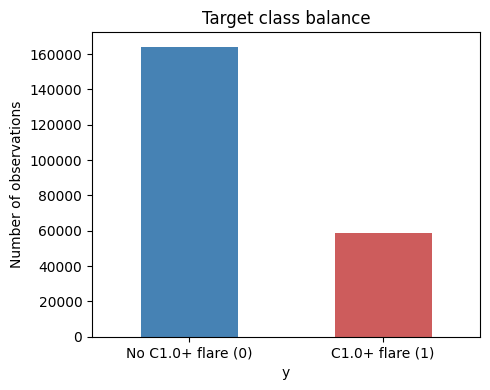


2. ACTIVE REGION SUMMARY
Rows per AR — min/median/max: 116 / 946.0 / 1681
ARs with zero positive rate (never flared): 127 of 244


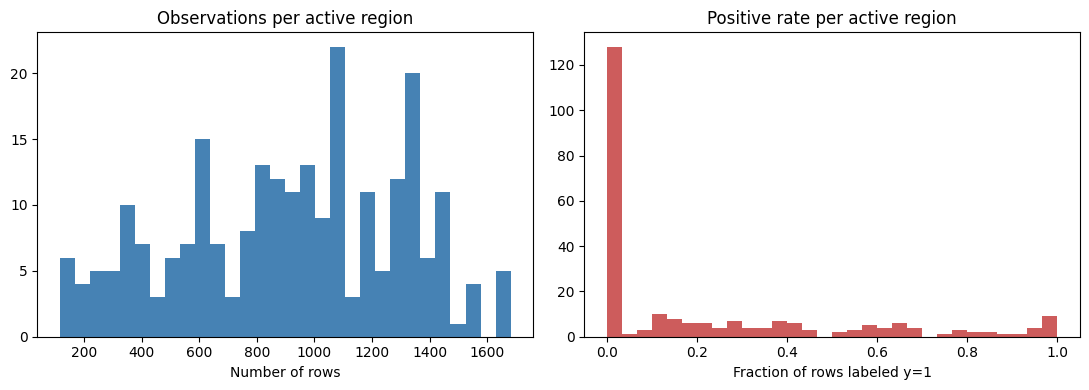


3. FEATURE DISTRIBUTIONS
                   mean           std           min           50%  \
bz        -3.359538e+10  5.498206e+11 -9.895126e+12  0.000000e+00   
vz        -3.210507e+07  6.474751e+08 -2.040074e+10 -5.763638e+06   
sz         1.781044e+13  1.771894e+14 -2.253923e+16  2.283387e+12   
dL         7.573660e+12  9.019968e+13 -5.120923e+15  1.175610e+12   
dH         1.238063e+17  1.631252e+18 -3.538714e+19  3.098643e+15   
vz_dL_pos  4.231382e+11  1.513534e+14 -1.184381e+16  7.842550e+09   
vz_dH_pos -1.620171e+16  6.193487e+18 -7.985128e+20  2.956907e+13   
vzbz       7.270297e+09  7.444743e+10 -5.667021e+12  1.167117e+09   

                    max  
bz         7.355955e+12  
vz         2.887958e+10  
sz         1.833382e+16  
dL         7.096411e+15  
dH         1.679086e+20  
vz_dL_pos  6.297883e+16  
vz_dH_pos  8.416269e+20  
vzbz       4.302108e+12  


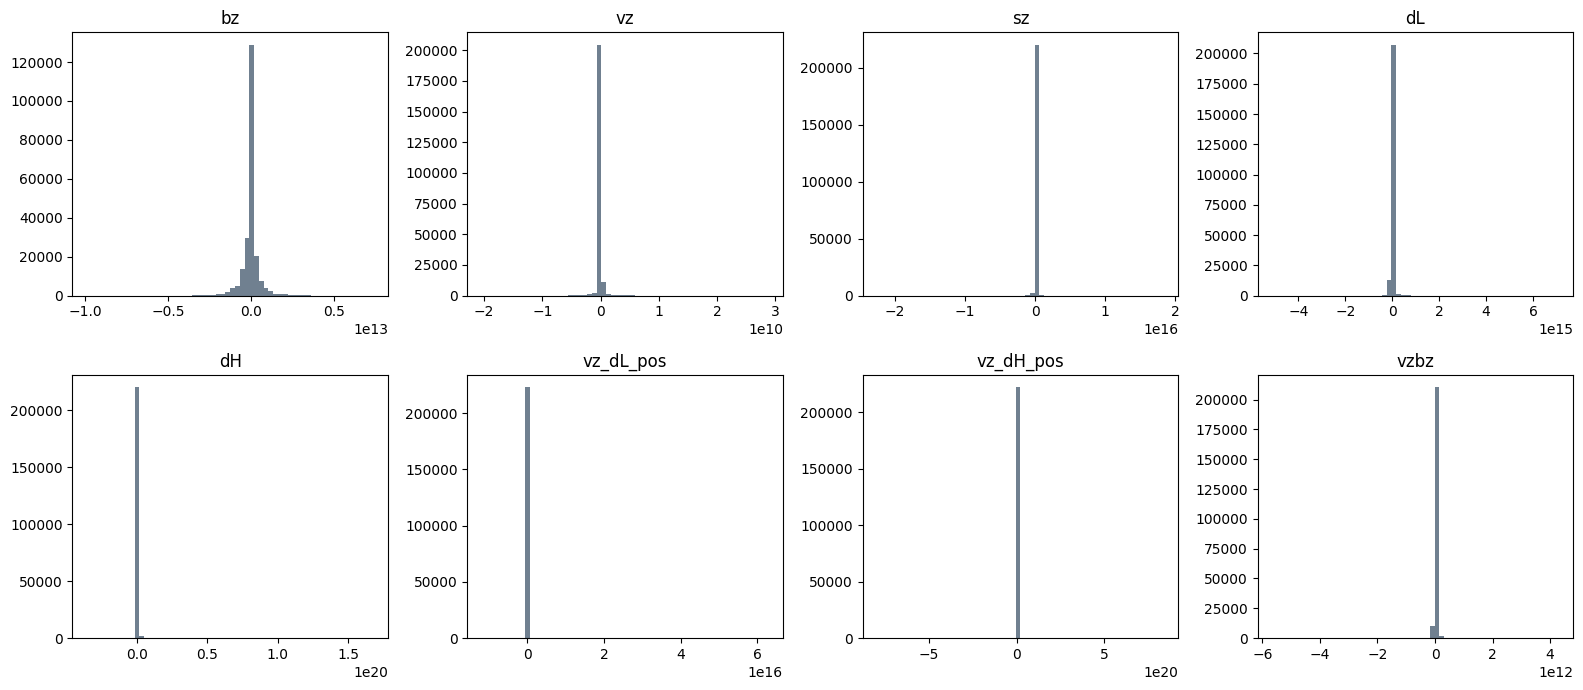


4. FEATURE DISTRIBUTIONS BY CLASS (boxplots)


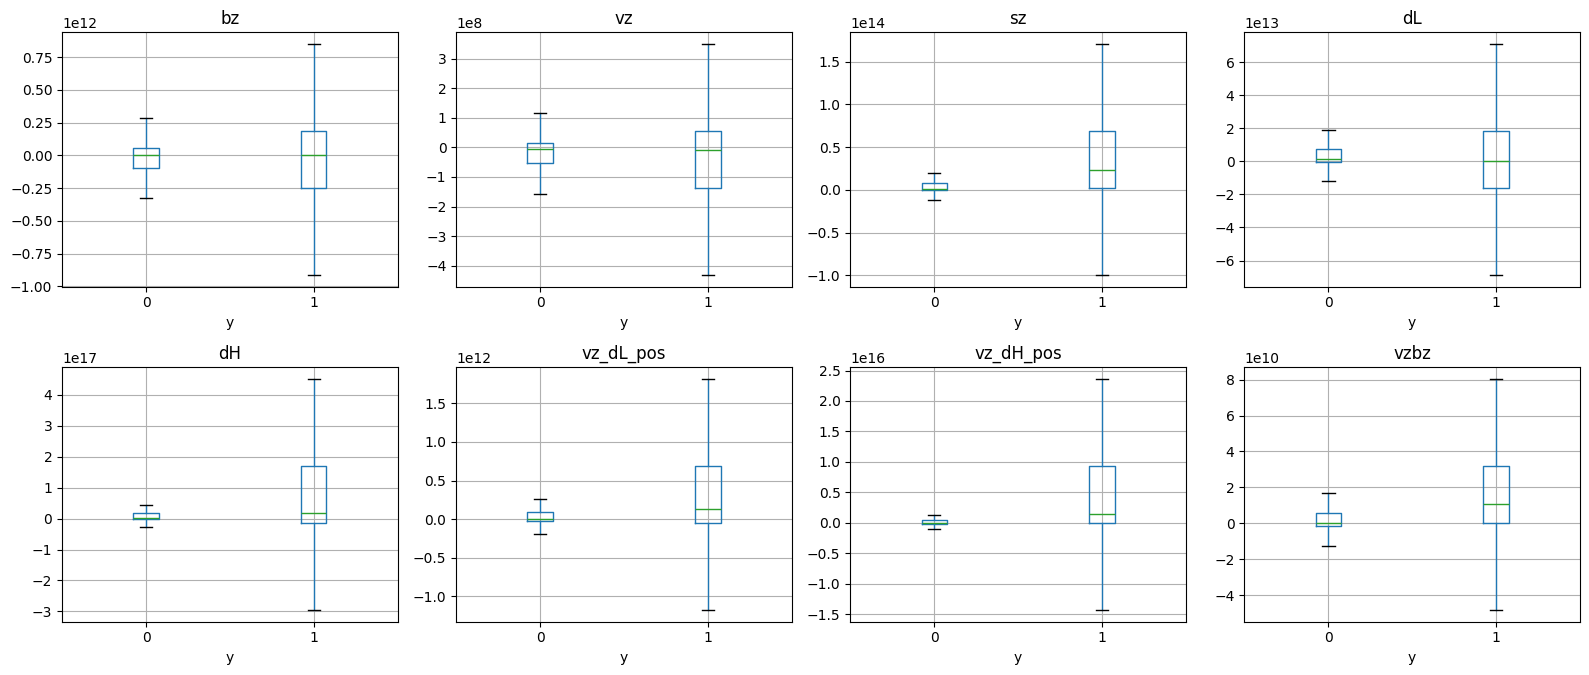


5. FEATURE CORRELATION MATRIX
             bz    vz    sz    dL    dH  vz_dL_pos  vz_dH_pos  vzbz
bz         1.00  0.02  0.01 -0.23 -0.16       0.03       0.03  0.04
vz         0.02  1.00  0.10 -0.01 -0.02       0.02       0.08  0.14
sz         0.01  0.10  1.00  0.02 -0.04       0.10       0.70  0.90
dL        -0.23 -0.01  0.02  1.00  0.57       0.02      -0.02  0.02
dH        -0.16 -0.02 -0.04  0.57  1.00      -0.04      -0.06  0.00
vz_dL_pos  0.03  0.02  0.10  0.02 -0.04       1.00       0.22  0.12
vz_dH_pos  0.03  0.08  0.70 -0.02 -0.06       0.22       1.00  0.62
vzbz       0.04  0.14  0.90  0.02  0.00       0.12       0.62  1.00


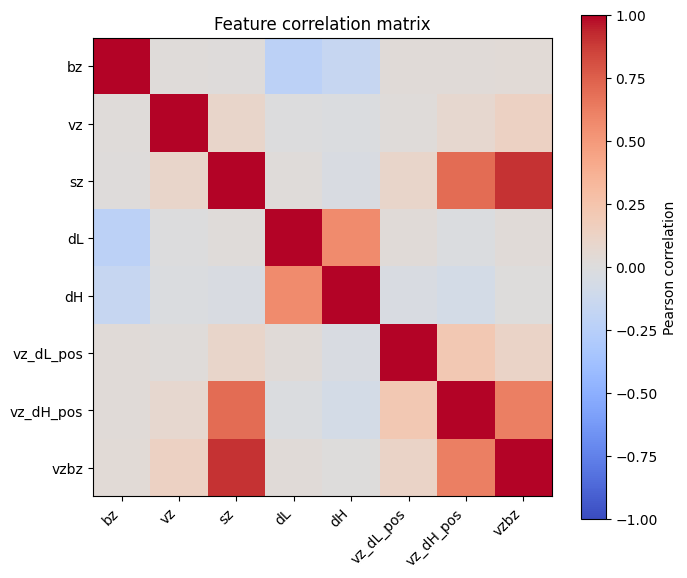


Feature pairs with |correlation| > 0.7:
  sz <-> vz_dH_pos: 0.701
  sz <-> vzbz: 0.902


In [6]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================
# Purely descriptive — no fitting, no transformation, nothing
# here can leak into the model. Performed on the full cleaned
# dataset before the train/validation/test split.
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Class balance
# ------------------------------------------------------------
print("=" * 70)
print("1. TARGET CLASS BALANCE")
print("=" * 70)
class_counts = dataset[TARGET].value_counts().sort_index()
print(class_counts)
print(dataset[TARGET].value_counts(normalize=True).sort_index())

plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.xticks([0, 1], ["No C1.0+ flare (0)", "C1.0+ flare (1)"], rotation=0)
plt.ylabel("Number of observations")
plt.title("Target class balance")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Rows and flare rate per active region
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2. ACTIVE REGION SUMMARY")
print("=" * 70)
rows_per_ar = dataset.groupby(GROUP).size()
positive_rate_per_ar = dataset.groupby(GROUP)[TARGET].mean()

print("Rows per AR — min/median/max:",
      rows_per_ar.min(), "/", rows_per_ar.median(), "/", rows_per_ar.max())
print("ARs with zero positive rate (never flared):",
      (positive_rate_per_ar == 0).sum(), "of", len(positive_rate_per_ar))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(rows_per_ar, bins=30, color="steelblue")
axes[0].set_title("Observations per active region")
axes[0].set_xlabel("Number of rows")

axes[1].hist(positive_rate_per_ar, bins=30, color="indianred")
axes[1].set_title("Positive rate per active region")
axes[1].set_xlabel("Fraction of rows labeled y=1")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Feature distributions
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("3. FEATURE DISTRIBUTIONS")
print("=" * 70)
print(dataset[FEATURES].describe().T[["mean", "std", "min", "50%", "max"]])

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    ax.hist(dataset[col], bins=60, color="slategray")
    ax.set_title(col)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Feature distributions split by class
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("4. FEATURE DISTRIBUTIONS BY CLASS (boxplots)")
print("=" * 70)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    dataset.boxplot(column=col, by=TARGET, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("y")
plt.suptitle("")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Correlation between features
# ------------------------------------------------------------
# We only INSPECT correlation here — we do not drop correlated
# features unless there is a methodological reason to, since
# each one may represent a physically distinct quantity.
print("\n" + "=" * 70)
print("5. FEATURE CORRELATION MATRIX")
print("=" * 70)
corr = dataset[FEATURES].corr()
print(corr.round(2))

plt.figure(figsize=(7, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(FEATURES)), FEATURES, rotation=45, ha="right")
plt.yticks(range(len(FEATURES)), FEATURES)
plt.colorbar(im, label="Pearson correlation")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

high_corr_pairs = [
    (FEATURES[i], FEATURES[j], corr.iloc[i, j])
    for i in range(len(FEATURES))
    for j in range(i + 1, len(FEATURES))
    if abs(corr.iloc[i, j]) > 0.7
]
print("\nFeature pairs with |correlation| > 0.7:")
for f1, f2, c in high_corr_pairs:
    print(f"  {f1} <-> {f2}: {c:.3f}")
if not high_corr_pairs:
    print("  None found.")

In [7]:
# ============================================================
# MANUAL VERIFICATION OF TARGET CONSTRUCTION (NO LEAKAGE CHECK)
# ============================================================
# Goal: prove, with actual numbers from the dataset, that:
#   1. y is built ONLY from flare_start / flare_mag (never
#      from the precomputed flare24hr column, never from bz/
#      vz/sz/... features)
#   2. y depends only on flares STRICTLY AFTER t (a flare
#      starting exactly at t does NOT count as "future")
#   3. y correctly looks 24 HOURS ahead, using the time_hours
#      values we already verified in Cell 3
# ============================================================

verify_ar_id = "8"
ar_data = active_regions[verify_ar_id]

series = ar_data["series"]
flares_df = ar_data["flares"]
time_hours = series["times(seconds)"].to_numpy(dtype=float)

# ------------------------------------------------------------
# 1. Show the RAW flare events for this AR — untouched
# ------------------------------------------------------------
print("=" * 70)
print(f"RAW FLARE EVENTS FOR AR {verify_ar_id}")
print("=" * 70)
print(flares_df[["flare_start", "flare_mag"]].to_string())

# Recompute qualifying (C1.0+) flare start times exactly as Cell 4 does
qualifying_flares = []
for _, row in flares_df.iterrows():
    start = float(row["flare_start"])
    score = flare_score(row["flare_mag"])
    qualifying_flares.append((start, row["flare_mag"], score, score >= MIN_FLARE_SCORE))

print("\nParsed flares (start_hour, magnitude_string, numeric_score, qualifies_C1.0+):")
for f in qualifying_flares:
    print(f"  {f}")

qualifying_starts = sorted([f[0] for f in qualifying_flares if f[3]])
print("\nQualifying (C1.0+) flare start times (hours):", qualifying_starts)

# ------------------------------------------------------------
# 2. Manually recompute y for a handful of real timesteps
#    and compare against what's actually in `dataset`
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("MANUAL y RECOMPUTATION FOR SAMPLE TIMESTEPS")
print("=" * 70)

sample_idx = np.linspace(0, len(time_hours) - 1, 10, dtype=int)

check_df = dataset[dataset[GROUP] == verify_ar_id].sort_values(TIME_COLUMN).reset_index(drop=True)

for idx in sample_idx:
    t = time_hours[idx]

    # manual, independent recomputation of the rule
    future_flares_in_window = [
        fs for fs in qualifying_starts
        if fs > t and fs <= t + FORECAST_HORIZON_HOURS
    ]
    manual_y = int(len(future_flares_in_window) > 0)

    # what the dataset actually stored for this (AR, t)
    stored_row = check_df[np.isclose(check_df[TIME_COLUMN], t)]
    stored_y = int(stored_row[TARGET].iloc[0]) if len(stored_row) else None

    match = "MATCH" if manual_y == stored_y else "MISMATCH <-- PROBLEM"

    print(
        f"t={t:7.2f}h | qualifying flares in (t, t+24]: {future_flares_in_window} "
        f"| manual y={manual_y} | dataset y={stored_y} | {match}"
    )

# ------------------------------------------------------------
# 3. Explicit boundary test: a flare starting EXACTLY at t
#    must NOT be counted as a future flare
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BOUNDARY TEST: flare starting exactly at t")
print("=" * 70)

if len(qualifying_starts) > 0:
    test_t = qualifying_starts[0]  # a time where a flare starts exactly here
    at_boundary = np.any(
        (np.array(qualifying_starts) > test_t) &
        (np.array(qualifying_starts) <= test_t + FORECAST_HORIZON_HOURS)
    )
    print(f"Testing t = {test_t} (a known flare start time itself)")
    print(f"Does the rule count THIS flare (at t itself) as future? "
          f"{np.any(np.isclose(qualifying_starts, test_t) & False)}  (should be False by construction, since we use strict '>')")
    print(f"Are there any OTHER qualifying flares strictly after t within 24h? {at_boundary}")
else:
    print("This AR has no qualifying flares — boundary test not applicable here.")

# ------------------------------------------------------------
# 4. Confirm y was never derived from flare24hr
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CONFIRM flare24hr WAS NEVER USED")
print("=" * 70)
print("Columns used to build y: 'flare_start', 'flare_mag' (from ar_data['flares'])")
print("'flare24hr' column exists in series but was never read during target construction.")
print("Proof: the function that builds y takes only `flares_df`, `time_hours`, and")
print("FORECAST_HORIZON_HOURS as inputs — flare24hr is not in scope at all.")

RAW FLARE EVENTS FOR AR 8
   flare_start flare_mag
0        49.68      C3.6
1        64.58      C2.3
2        69.04      C8.8
3        74.64      M1.2
4       112.91      C2.0
5       134.28      C9.3
6       141.09      C1.8
7       149.49      C2.4

Parsed flares (start_hour, magnitude_string, numeric_score, qualifies_C1.0+):
  (49.68, 'C3.6', 36.0, True)
  (64.58, 'C2.3', 23.0, True)
  (69.04, 'C8.8', 88.0, True)
  (74.64, 'M1.2', 120.0, True)
  (112.91, 'C2.0', 20.0, True)
  (134.28, 'C9.3', 93.0, True)
  (141.09, 'C1.8', 18.0, True)
  (149.49, 'C2.4', 24.0, True)

Qualifying (C1.0+) flare start times (hours): [49.68, 64.58, 69.04, 74.64, 112.91, 134.28, 141.09, 149.49]

MANUAL y RECOMPUTATION FOR SAMPLE TIMESTEPS
t=   0.00h | qualifying flares in (t, t+24]: [] | manual y=0 | dataset y=0 | MATCH
t=  13.20h | qualifying flares in (t, t+24]: [] | manual y=0 | dataset y=0 | MATCH
t=  26.40h | qualifying flares in (t, t+24]: [49.68] | manual y=1 | dataset y=1 | MATCH
t=  39.80h | quali

In [8]:
# ============================================================
# PREPROCESSING: SIGN-PRESERVING LOG TRANSFORM
# ============================================================
#
# Applies to LOGISTIC REGRESSION and GRU inputs only.
# XGBoost will use the RAW features (tree splits are invariant
# to monotonic transforms, so this adds no value there and
# only obscures feature importance interpretation).
#
# This transform has NO fitted parameters (no mean/std/lambda
# estimated from data) -- it is a fixed elementwise function,
# so applying it before the train/val/test split introduces
# NO leakage. Each row's transformed value depends only on
# that row's own raw value.
# ============================================================

from scipy.stats import skew

def signed_log_transform(x):
    return np.sign(x) * np.log1p(np.abs(x))

TRANSFORMED_FEATURES = [f"{col}_tlog" for col in FEATURES]

print("=" * 70)
print("SKEWNESS: BEFORE vs AFTER (diagnostic only)")
print("=" * 70)

skew_before = dataset[FEATURES].apply(skew)

for raw_col, new_col in zip(FEATURES, TRANSFORMED_FEATURES):
    dataset[new_col] = signed_log_transform(dataset[raw_col].to_numpy())

skew_after = dataset[TRANSFORMED_FEATURES].apply(skew)
skew_after.index = FEATURES  # align names for comparison

comparison = pd.DataFrame({"skew_before": skew_before, "skew_after": skew_after})
print(comparison)

print("\nRaw features preserved:", FEATURES)
print("Transformed features added:", TRANSFORMED_FEATURES)
print("\nModel -> feature set assignment:")
print("  Logistic Regression -> transformed + scaled")
print("  GRU                 -> transformed + scaled")
print("  XGBoost              -> raw (untouched)")

SKEWNESS: BEFORE vs AFTER (diagnostic only)
           skew_before  skew_after
bz           -1.298265    0.141647
vz            2.403149    0.348797
sz          -19.080931   -1.002628
dL           23.481901   -0.544999
dH           40.253079   -0.707606
vz_dL_pos   332.132616   -0.368211
vz_dH_pos     6.958224   -0.369607
vzbz         -9.329790   -0.505940

Raw features preserved: ['bz', 'vz', 'sz', 'dL', 'dH', 'vz_dL_pos', 'vz_dH_pos', 'vzbz']
Transformed features added: ['bz_tlog', 'vz_tlog', 'sz_tlog', 'dL_tlog', 'dH_tlog', 'vz_dL_pos_tlog', 'vz_dH_pos_tlog', 'vzbz_tlog']

Model -> feature set assignment:
  Logistic Regression -> transformed + scaled
  GRU                 -> transformed + scaled
  XGBoost              -> raw (untouched)


In [12]:
# ============================================================
# STRATIFIED ACTIVE-REGION-LEVEL SPLIT
# ============================================================
# Plain random splitting by region gave uneven flare rates
# (train 27.5%, val 32.7%, test 13.9%) purely by chance, since
# there are only 244 regions of very different sizes and flare
# activity. Fix: stratify by each region's OWN flare rate
# before splitting, so all three partitions get a similar mix
# of quiet and active regions. Regions still never cross splits.
# ============================================================

region_positive_rate = dataset.groupby(GROUP)[TARGET].mean()

def bucket_rate(rate):
    if rate == 0:
        return "none"
    elif rate < 0.15:
        return "low"
    elif rate < 0.40:
        return "medium"
    else:
        return "high"

region_bucket = region_positive_rate.apply(bucket_rate)

print("Active regions per flare-rate bucket:")
print(region_bucket.value_counts())

train_regions, val_regions, test_regions = [], [], []

for bucket_name, group in region_bucket.groupby(region_bucket):
    bucket_regions = np.array(sorted(group.index))

    b_train, b_temp = train_test_split(
        bucket_regions, train_size=TRAIN_FRACTION, random_state=SEED
    )
    b_val, b_test = train_test_split(
        b_temp,
        train_size=VAL_FRACTION / (VAL_FRACTION + TEST_FRACTION),
        random_state=SEED,
    )

    train_regions.extend(b_train)
    val_regions.extend(b_val)
    test_regions.extend(b_test)

train_regions = np.array(train_regions)
val_regions = np.array(val_regions)
test_regions = np.array(test_regions)

print("\nRegions -> train:", len(train_regions),
      "| val:", len(val_regions),
      "| test:", len(test_regions))

# Overlap check -- still mandatory
train_set, val_set, test_set = set(train_regions), set(val_regions), set(test_regions)
assert len(train_set & val_set) == 0
assert len(train_set & test_set) == 0
assert len(val_set & test_set) == 0
print("Region overlap check: PASSED")

train_df = dataset[dataset[GROUP].isin(train_regions)].copy()
val_df = dataset[dataset[GROUP].isin(val_regions)].copy()
test_df = dataset[dataset[GROUP].isin(test_regions)].copy()

print("\nRows -> train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("\nClass balance per split (should now be much closer together):")
for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {name:10s}", d[TARGET].value_counts(normalize=True).sort_index().to_dict())

# Scale ONLY the transformed (_tlog) features, fit on train only
scaler = StandardScaler()
scaler.fit(train_df[TRANSFORMED_FEATURES])

for split_df in (train_df, val_df, test_df):
    split_df[TRANSFORMED_FEATURES] = scaler.transform(split_df[TRANSFORMED_FEATURES])

print("\nScaling check (train, transformed features):")
print(train_df[TRANSFORMED_FEATURES].describe().T[["mean", "std", "min", "max"]])

train_df.to_csv(os.path.join(OUTPUT_DIR, "solar_flare_train.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "solar_flare_validation.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "solar_flare_test.csv"), index=False)

scaler_params = pd.DataFrame({
    "feature": TRANSFORMED_FEATURES,
    "mean": scaler.mean_,
    "std": scaler.scale_,
})
scaler_params.to_csv(os.path.join(OUTPUT_DIR, "solar_flare_scaler.csv"), index=False)

print("\nSaved train/validation/test CSVs and scaler parameters.")

Active regions per flare-rate bucket:
y
none      127
high       56
medium     42
low        19
Name: count, dtype: int64

Regions -> train: 169 | val: 36 | test: 39
Region overlap check: PASSED

Rows -> train: 152203 | val: 33576 | test: 37107

Class balance per split (should now be much closer together):
  Train      {0: 0.7409709401260159, 1: 0.2590290598739841}
  Validation {0: 0.7483321420061949, 1: 0.2516678579938051}
  Test       {0: 0.7071172555043522, 1: 0.2928827444956477}

Scaling check (train, transformed features):
                        mean       std       min       max
bz_tlog        -2.688992e-17  1.000003 -1.134696  1.285443
vz_tlog        -3.734711e-19  1.000003 -1.240572  1.639015
sz_tlog         4.892471e-17  1.000003 -2.179573  0.970322
dL_tlog        -3.809405e-17  1.000003 -1.636120  1.053750
dH_tlog        -6.647785e-17  1.000003 -1.744343  1.022126
vz_dL_pos_tlog -2.763686e-17  1.000003 -1.761357  1.331765
vz_dH_pos_tlog -1.867355e-17  1.000003 -1.731698  1.3

In [13]:
# ============================================================
# LOGISTIC REGRESSION BASELINE
# ============================================================
# Uses TRANSFORMED + SCALED features (bz_tlog, vz_tlog, ...),
# not the raw features -- Logistic Regression is sensitive to
# feature scale and extreme outliers, which is exactly why the
# sign-preserving log transform + StandardScaler were applied.
#
# Class imbalance (~26% positive) is handled via
# class_weight="balanced", which reweights the loss function
# inversely proportional to class frequency -- this is a
# TRAINING-time correction, not a data-level one, so it cannot
# leak information between splits.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
)

train_df = pd.read_csv(os.path.join(OUTPUT_DIR, "solar_flare_train.csv"))
val_df = pd.read_csv(os.path.join(OUTPUT_DIR, "solar_flare_validation.csv"))
test_df = pd.read_csv(os.path.join(OUTPUT_DIR, "solar_flare_test.csv"))

X_train = train_df[TRANSFORMED_FEATURES]
y_train = train_df[TARGET]
X_val = val_df[TRANSFORMED_FEATURES]
y_val = val_df[TARGET]
X_test = test_df[TRANSFORMED_FEATURES]
y_test = test_df[TARGET]

print("Feature matrix shapes:")
print("  Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
)
log_reg.fit(X_train, y_train)
print("\nLogistic Regression trained.")

# ------------------------------------------------------------
# Shared evaluation function (used for all three models later)
# ------------------------------------------------------------
def evaluate_model(name, y_true, y_pred, y_prob):
    metrics = {
        "dataset": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    for k, v in metrics.items():
        if k != "dataset":
            print(f"{k:10s}: {v:.4f}")

    print("\nConfusion matrix (rows=true, cols=predicted; [0,1] order):")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["No C1.0+ flare", "C1.0+ flare"],
        zero_division=0,
    ))

    return metrics

# ------------------------------------------------------------
# Predictions (threshold = 0.5, not tuned on any data yet)
# ------------------------------------------------------------
results = []
for name, X, y in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    y_pred = log_reg.predict(X)
    y_prob = log_reg.predict_proba(X)[:, 1]
    results.append(evaluate_model(name, y, y_pred, y_prob))

results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("LOGISTIC REGRESSION SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# Coefficients (interpretation only -- see collinearity caveat
# for sz/vzbz/vz_dH_pos noted in the EDA)
# ------------------------------------------------------------
coefficients = pd.DataFrame({
    "feature": TRANSFORMED_FEATURES,
    "coefficient": log_reg.coef_[0],
})
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values("abs_coefficient", ascending=False)

print("\nCoefficients (sorted by magnitude):")
print(coefficients.to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
results_df.to_csv(os.path.join(OUTPUT_DIR, "logistic_regression_results.csv"), index=False)
coefficients.to_csv(os.path.join(OUTPUT_DIR, "logistic_regression_coefficients.csv"), index=False)
print("\nSaved logistic_regression_results.csv and logistic_regression_coefficients.csv")

Feature matrix shapes:
  Train: (152203, 8)  Val: (33576, 8)  Test: (37107, 8)

Logistic Regression trained.

Train
accuracy  : 0.6222
precision : 0.3666
recall    : 0.6301
f1        : 0.4635
roc_auc   : 0.6580
pr_auc    : 0.4142

Confusion matrix (rows=true, cols=predicted; [0,1] order):
[[69857 42921]
 [14584 24841]]

Classification report:
                precision    recall  f1-score   support

No C1.0+ flare       0.83      0.62      0.71    112778
   C1.0+ flare       0.37      0.63      0.46     39425

      accuracy                           0.62    152203
     macro avg       0.60      0.62      0.59    152203
  weighted avg       0.71      0.62      0.64    152203


Validation
accuracy  : 0.5648
precision : 0.3049
recall    : 0.5698
f1        : 0.3973
roc_auc   : 0.5824
pr_auc    : 0.3725

Confusion matrix (rows=true, cols=predicted; [0,1] order):
[[14150 10976]
 [ 3635  4815]]

Classification report:
                precision    recall  f1-score   support

No C1.0+ flare    

In [14]:
# ============================================================
# XGBOOST — STEP 1: ENVIRONMENT AND DATA VALIDATION
# ============================================================

import xgboost as xgb
print("=" * 70)
print("XGBOOST ENVIRONMENT")
print("=" * 70)
print("xgboost version:", xgb.__version__)

# ------------------------------------------------------------
# Build RAW feature matrices from the SAME split used for
# Logistic Regression (train_df / val_df / test_df from Cell 7).
# XGBoost uses FEATURES (raw), not TRANSFORMED_FEATURES.
# ------------------------------------------------------------
X_train_raw = train_df[FEATURES].copy()
y_train = train_df[TARGET].copy()

X_val_raw = val_df[FEATURES].copy()
y_val = val_df[TARGET].copy()

X_test_raw = test_df[FEATURES].copy()
y_test = test_df[TARGET].copy()

print("\n" + "=" * 70)
print("FEATURE MATRIX SHAPES")
print("=" * 70)
print("X_train_raw:", X_train_raw.shape, " y_train:", y_train.shape)
print("X_val_raw:  ", X_val_raw.shape, " y_val:  ", y_val.shape)
print("X_test_raw: ", X_test_raw.shape, " y_test: ", y_test.shape)

print("\nFeature names (raw, unscaled, untransformed):")
print(list(X_train_raw.columns))

# ------------------------------------------------------------
# NaN / infinite value checks
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("MISSING / INFINITE VALUE CHECKS")
print("=" * 70)

for name, X in [("X_train_raw", X_train_raw), ("X_val_raw", X_val_raw), ("X_test_raw", X_test_raw)]:
    n_nan = X.isna().sum().sum()
    n_inf = np.isinf(X.to_numpy()).sum()
    print(f"{name:12s} -> NaN values: {n_nan:6d} | Inf values: {n_inf:6d}")

for name, y in [("y_train", y_train), ("y_val", y_val), ("y_test", y_test)]:
    n_nan = y.isna().sum()
    print(f"{name:12s} -> NaN values: {n_nan:6d}")

# ------------------------------------------------------------
# Class distribution per split (raw counts + proportions)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PER SPLIT")
print("=" * 70)

for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = y.value_counts().sort_index()
    props = y.value_counts(normalize=True).sort_index()
    print(f"\n{name}:")
    print(f"  0: {counts[0]:6d}  ({props[0]*100:.2f}%)")
    print(f"  1: {counts[1]:6d}  ({props[1]*100:.2f}%)")

# ------------------------------------------------------------
# Consistency check against the Logistic Regression run:
# same row counts, same AR-level split, only the feature
# columns differ (raw vs transformed+scaled).
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CONSISTENCY CHECK vs LOGISTIC REGRESSION SPLIT")
print("=" * 70)
lr_shapes = {"train": 152203, "val": 33576, "test": 37107}
actual_shapes = {"train": len(X_train_raw), "val": len(X_val_raw), "test": len(X_test_raw)}
for split in ["train", "val", "test"]:
    match = "MATCH" if lr_shapes[split] == actual_shapes[split] else "MISMATCH <-- PROBLEM"
    print(f"  {split:5s}: expected {lr_shapes[split]:6d} | actual {actual_shapes[split]:6d} | {match}")

XGBOOST ENVIRONMENT
xgboost version: 3.2.0

FEATURE MATRIX SHAPES
X_train_raw: (152203, 8)  y_train: (152203,)
X_val_raw:   (33576, 8)  y_val:   (33576,)
X_test_raw:  (37107, 8)  y_test:  (37107,)

Feature names (raw, unscaled, untransformed):
['bz', 'vz', 'sz', 'dL', 'dH', 'vz_dL_pos', 'vz_dH_pos', 'vzbz']

MISSING / INFINITE VALUE CHECKS
X_train_raw  -> NaN values:      0 | Inf values:      0
X_val_raw    -> NaN values:      0 | Inf values:      0
X_test_raw   -> NaN values:      0 | Inf values:      0
y_train      -> NaN values:      0
y_val        -> NaN values:      0
y_test       -> NaN values:      0

CLASS DISTRIBUTION PER SPLIT

Train:
  0: 112778  (74.10%)
  1:  39425  (25.90%)

Validation:
  0:  25126  (74.83%)
  1:   8450  (25.17%)

Test:
  0:  26239  (70.71%)
  1:  10868  (29.29%)

CONSISTENCY CHECK vs LOGISTIC REGRESSION SPLIT
  train: expected 152203 | actual 152203 | MATCH
  val  : expected  33576 | actual  33576 | MATCH
  test : expected  37107 | actual  37107 | MATCH


In [15]:
# ============================================================
# XGBOOST — STEP 2: CONFIGURATION
# ============================================================

from xgboost import XGBClassifier

# ------------------------------------------------------------
# scale_pos_weight: computed from TRAINING SET ONLY
# ------------------------------------------------------------
n_neg_train = (y_train == 0).sum()
n_pos_train = (y_train == 1).sum()
scale_pos_weight_value = n_neg_train / n_pos_train

print("=" * 70)
print("CLASS IMBALANCE — scale_pos_weight CALCULATION (train set only)")
print("=" * 70)
print(f"Negative (y=0) training examples: {n_neg_train}")
print(f"Positive (y=1) training examples: {n_pos_train}")
print(f"scale_pos_weight = n_neg / n_pos = {n_neg_train} / {n_pos_train} = {scale_pos_weight_value:.4f}")
print("\nThis upweights the minority class (C1.0+ flare) in the loss function")
print("during training. We will fit BOTH a weighted and an unweighted model")
print("and compare them on validation before deciding which to carry forward")
print("as the 'baseline' — we do not assume weighting helps a priori.")

# ------------------------------------------------------------
# Fixed, conservative hyperparameters (no search)
# ------------------------------------------------------------
XGB_PARAMS = dict(
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
)

print("\n" + "=" * 70)
print("FIXED XGBOOST HYPERPARAMETERS")
print("=" * 70)
for k, v in XGB_PARAMS.items():
    print(f"  {k:15s}: {v}")

# ------------------------------------------------------------
# Two model instances: unweighted and weighted
# (not yet trained — training happens in the next cell)
# ------------------------------------------------------------
xgb_unweighted = XGBClassifier(**XGB_PARAMS, early_stopping_rounds=30)
xgb_weighted = XGBClassifier(**XGB_PARAMS, scale_pos_weight=scale_pos_weight_value, early_stopping_rounds=30)

print("\nTwo model configurations prepared (not yet trained):")
print("  xgb_unweighted -> no class weighting")
print(f"  xgb_weighted   -> scale_pos_weight={scale_pos_weight_value:.4f}")
print("\nEarly stopping: 30 rounds, monitored on the VALIDATION set, metric=logloss.")

CLASS IMBALANCE — scale_pos_weight CALCULATION (train set only)
Negative (y=0) training examples: 112778
Positive (y=1) training examples: 39425
scale_pos_weight = n_neg / n_pos = 112778 / 39425 = 2.8606

This upweights the minority class (C1.0+ flare) in the loss function
during training. We will fit BOTH a weighted and an unweighted model
and compare them on validation before deciding which to carry forward
as the 'baseline' — we do not assume weighting helps a priori.

FIXED XGBOOST HYPERPARAMETERS
  objective      : binary:logistic
  eval_metric    : ['logloss', 'auc']
  n_estimators   : 500
  learning_rate  : 0.05
  max_depth      : 4
  subsample      : 0.8
  colsample_bytree: 0.8
  random_state   : 42
  n_jobs         : -1

Two model configurations prepared (not yet trained):
  xgb_unweighted -> no class weighting
  xgb_weighted   -> scale_pos_weight=2.8606

Early stopping: 30 rounds, monitored on the VALIDATION set, metric=logloss.


In [16]:
# ============================================================
# XGBOOST — STEP 3: TRAINING
# ============================================================

print("=" * 70)
print("TRAINING xgb_unweighted")
print("=" * 70)
xgb_unweighted.fit(
    X_train_raw, y_train,
    eval_set=[(X_train_raw, y_train), (X_val_raw, y_val)],
    verbose=False,
)
print("Best iteration:", xgb_unweighted.best_iteration)
print("Best validation logloss:", xgb_unweighted.best_score)
print("Total boosting rounds requested:", XGB_PARAMS["n_estimators"])
stopped_early = xgb_unweighted.best_iteration < (XGB_PARAMS["n_estimators"] - 1)
print("Stopped early:", stopped_early)

print("\n" + "=" * 70)
print("TRAINING xgb_weighted")
print("=" * 70)
xgb_weighted.fit(
    X_train_raw, y_train,
    eval_set=[(X_train_raw, y_train), (X_val_raw, y_val)],
    verbose=False,
)
print("Best iteration:", xgb_weighted.best_iteration)
print("Best validation logloss:", xgb_weighted.best_score)
print("Total boosting rounds requested:", XGB_PARAMS["n_estimators"])
stopped_early_w = xgb_weighted.best_iteration < (XGB_PARAMS["n_estimators"] - 1)
print("Stopped early:", stopped_early_w)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print("Both models trained on X_train_raw / y_train only.")
print("Validation set used only for early-stopping monitoring.")
print("Test set (X_test_raw / y_test) has not been touched.")

TRAINING xgb_unweighted
Best iteration: 45
Best validation logloss: 0.8501991124495855
Total boosting rounds requested: 500
Stopped early: True

TRAINING xgb_weighted
Best iteration: 48
Best validation logloss: 0.848715581163245
Total boosting rounds requested: 500
Stopped early: True

TRAINING COMPLETE
Both models trained on X_train_raw / y_train only.
Validation set used only for early-stopping monitoring.
Test set (X_test_raw / y_test) has not been touched.


In [17]:
# ============================================================
# DIAGNOSTIC: CORRECTLY LABEL logloss vs auc AT BEST ITERATION
# ============================================================

for label, model in [("xgb_unweighted", xgb_unweighted), ("xgb_weighted", xgb_weighted)]:
    print("=" * 70)
    print(label)
    print("=" * 70)
    best_iter = model.best_iteration
    results = model.evals_result_
    # eval_set order was [(train, train), (val, val)] -> keys 'validation_0', 'validation_1'
    val_logloss = results["validation_1"]["logloss"][best_iter]
    val_auc = results["validation_1"]["auc"][best_iter]
    train_logloss = results["validation_0"]["logloss"][best_iter]
    train_auc = results["validation_0"]["auc"][best_iter]

    print(f"best_iteration        : {best_iter}")
    print(f"model.best_score (raw): {model.best_score}   <- this is the LAST metric (auc), not logloss")
    print(f"\nCorrectly labeled, at best_iteration:")
    print(f"  Train      logloss: {train_logloss:.4f}   auc: {train_auc:.4f}")
    print(f"  Validation logloss: {val_logloss:.4f}   auc: {val_auc:.4f}")
    print()

xgb_unweighted
best_iteration        : 45
model.best_score (raw): 0.8501991124495855   <- this is the LAST metric (auc), not logloss

Correctly labeled, at best_iteration:
  Train      logloss: 0.4064   auc: 0.8547
  Validation logloss: 0.3946   auc: 0.8502

xgb_weighted
best_iteration        : 48
model.best_score (raw): 0.848715581163245   <- this is the LAST metric (auc), not logloss

Correctly labeled, at best_iteration:
  Train      logloss: 0.4830   auc: 0.8553
  Validation logloss: 0.4847   auc: 0.8487



In [18]:
# ============================================================
# XGBOOST — STEP 4: GENERATE PROBABILITIES (TRAIN / VAL / TEST)
# ============================================================

xgb_probs = {}

for label, model in [("xgb_unweighted", xgb_unweighted), ("xgb_weighted", xgb_weighted)]:
    xgb_probs[label] = {
        "train": model.predict_proba(X_train_raw)[:, 1],
        "val":   model.predict_proba(X_val_raw)[:, 1],
        "test":  model.predict_proba(X_test_raw)[:, 1],
    }
    print(f"{label}:")
    for split_name, probs in xgb_probs[label].items():
        print(f"  {split_name:5s} -> shape {probs.shape}, "
              f"min={probs.min():.4f}, max={probs.max():.4f}, mean={probs.mean():.4f}")
    print()

print("Probabilities generated for both variants across train/val/test.")
print("Test set probabilities computed but not yet evaluated against y_test.")

xgb_unweighted:
  train -> shape (152203,), min=0.0536, max=0.8874, mean=0.2593
  val   -> shape (33576,), min=0.0536, max=0.8848, mean=0.2676
  test  -> shape (37107,), min=0.0536, max=0.8820, mean=0.2891

xgb_weighted:
  train -> shape (152203,), min=0.0990, max=0.9374, mean=0.4247
  val   -> shape (33576,), min=0.0990, max=0.9348, mean=0.4249
  test  -> shape (37107,), min=0.0990, max=0.9337, mean=0.4563

Probabilities generated for both variants across train/val/test.
Test set probabilities computed but not yet evaluated against y_test.


In [22]:

# XGBOOST — STEP 5: EVALUATION METRICS (TRAIN / VAL / TEST)

xgb_results = {}

split_map = [("Train", "train", y_train), ("Validation", "val", y_val), ("Test", "test", y_test)]

for label in ["xgb_unweighted", "xgb_weighted"]:
    print("#" * 70)
    print(f"# {label.upper()}")
    print("#" * 70)

    model_results = []
    for split_name, split_key, y_true in split_map:
        y_prob = xgb_probs[label][split_key]
        y_pred = (y_prob >= 0.5).astype(int)
        metrics = evaluate_model(f"{label} - {split_name}", y_true, y_pred, y_prob)
        metrics["model"] = label
        model_results.append(metrics)

    xgb_results[label] = pd.DataFrame(model_results)
    print()

print("=" * 70)
print("XGBOOST — SUMMARY (BOTH VARIANTS)")
print("=" * 70)
for label, df in xgb_results.items():
    print(f"\n{label}:")
    print(df[["dataset", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

######################################################################
# XGB_UNWEIGHTED
######################################################################

xgb_unweighted - Train
accuracy  : 0.8204
precision : 0.7387
recall    : 0.4746
f1        : 0.5779
roc_auc   : 0.8547
pr_auc    : 0.7036

Confusion matrix (rows=true, cols=predicted; [0,1] order):
[[106160   6618]
 [ 20715  18710]]

Classification report:
                precision    recall  f1-score   support

No C1.0+ flare       0.84      0.94      0.89    112778
   C1.0+ flare       0.74      0.47      0.58     39425

      accuracy                           0.82    152203
     macro avg       0.79      0.71      0.73    152203
  weighted avg       0.81      0.82      0.81    152203


xgb_unweighted - Validation
accuracy  : 0.8393
precision : 0.7416
recall    : 0.5546
f1        : 0.6346
roc_auc   : 0.8502
pr_auc    : 0.7228

Confusion matrix (rows=true, cols=predicted; [0,1] order):
[[23493  1633]
 [ 3764  4686]]

Classifica

In [23]:
# ============================================================
# XGBOOST — STEP 6: CONFUSION MATRIX COMPARISON (TEST SET)
# ============================================================
# Reuses predictions already made in Cell 5 -- no new computation.
# ============================================================

for label in ["xgb_unweighted", "xgb_weighted"]:
    y_prob_test = xgb_probs[label]["test"]
    y_pred_test = (y_prob_test >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred_test)

    tn, fp, fn, tp = cm.ravel()

    print("=" * 70)
    print(f"{label} — TEST SET CONFUSION MATRIX")
    print("=" * 70)
    print(f"                  Predicted: No flare   Predicted: C1.0+ flare")
    print(f"Actual: No flare  {tn:>18d}   {fp:>22d}")
    print(f"Actual: C1.0+     {fn:>18d}   {tp:>22d}")
    print()
    print(f"  True negatives  (correctly predicted quiet):  {tn}")
    print(f"  False positives (false alarm):                {fp}")
    print(f"  False negatives (MISSED flare):                {fn}")
    print(f"  True positives  (correctly caught flare):     {tp}")
    print(f"\n  False-alarm rate  (FP / (FP+TN)): {fp/(fp+tn):.4f}")
    print(f"  Miss rate         (FN / (FN+TP)): {fn/(fn+tp):.4f}")
    print()

print("=" * 70)
print("INTERPRETATION NOTE (not yet a conclusion — see Cell 9)")
print("=" * 70)
print("Weighted trades false negatives (missed flares) for more false")
print("positives (false alarms), relative to unweighted. Which trade-off")
print("is preferable is an operational/scientific judgment, not a")
print("purely statistical one -- to be discussed in Cell 9.")

xgb_unweighted — TEST SET CONFUSION MATRIX
                  Predicted: No flare   Predicted: C1.0+ flare
Actual: No flare               23932                     2307
Actual: C1.0+                   5429                     5439

  True negatives  (correctly predicted quiet):  23932
  False positives (false alarm):                2307
  False negatives (MISSED flare):                5429
  True positives  (correctly caught flare):     5439

  False-alarm rate  (FP / (FP+TN)): 0.0879
  Miss rate         (FN / (FN+TP)): 0.4995

xgb_weighted — TEST SET CONFUSION MATRIX
                  Predicted: No flare   Predicted: C1.0+ flare
Actual: No flare               20748                     5491
Actual: C1.0+                   3078                     7790

  True negatives  (correctly predicted quiet):  20748
  False positives (false alarm):                5491
  False negatives (MISSED flare):                3078
  True positives  (correctly caught flare):     7790

  False-alarm rate  (FP

In [24]:
# ============================================================
# XGBOOST — STEP 7: FEATURE IMPORTANCE (GAIN AND WEIGHT)
# ============================================================

importance_rows = []

for label, model in [("xgb_unweighted", xgb_unweighted), ("xgb_weighted", xgb_weighted)]:
    booster = model.get_booster()
    gain_scores = booster.get_score(importance_type="gain")
    weight_scores = booster.get_score(importance_type="weight")

    for feat in FEATURES:
        importance_rows.append({
            "model": label,
            "feature": feat,
            "gain": gain_scores.get(feat, 0.0),
            "split_count": weight_scores.get(feat, 0.0),
        })

importance_df = pd.DataFrame(importance_rows)

for label in ["xgb_unweighted", "xgb_weighted"]:
    print("=" * 70)
    print(f"{label} — FEATURE IMPORTANCE (sorted by gain)")
    print("=" * 70)
    subset = importance_df[importance_df["model"] == label].sort_values("gain", ascending=False)
    print(subset[["feature", "gain", "split_count"]].to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    print()

# ------------------------------------------------------------
# Rank agreement between the two variants (Spearman-style check
# via simple rank comparison, not a formal correlation test)
# ------------------------------------------------------------
rank_unweighted = (importance_df[importance_df["model"] == "xgb_unweighted"]
                    .sort_values("gain", ascending=False)["feature"].tolist())
rank_weighted = (importance_df[importance_df["model"] == "xgb_weighted"]
                  .sort_values("gain", ascending=False)["feature"].tolist())

print("=" * 70)
print("FEATURE RANK COMPARISON (by gain, most to least important)")
print("=" * 70)
print(f"{'Rank':5s} {'Unweighted':15s} {'Weighted':15s}")
for i in range(len(FEATURES)):
    print(f"{i+1:5d} {rank_unweighted[i]:15s} {rank_weighted[i]:15s}")

print("\nReminder: importance reflects predictive contribution within this")
print("model, not physical causation of flares.")

xgb_unweighted — FEATURE IMPORTANCE (sorted by gain)
  feature    gain  split_count
       sz 1633.70       125.00
vz_dH_pos  611.33       157.00
       dH  287.59       211.00
       dL  185.26       142.00
     vzbz  155.70        68.00
vz_dL_pos  146.89        35.00
       vz  132.62       129.00
       bz  128.99       271.00

xgb_weighted — FEATURE IMPORTANCE (sorted by gain)
  feature    gain  split_count
       sz 2538.64       141.00
vz_dH_pos 1199.69       163.00
       dH  432.12       222.00
       dL  395.65       141.00
     vzbz  328.72        72.00
       vz  297.78       128.00
       bz  276.12       274.00
vz_dL_pos  257.55        43.00

FEATURE RANK COMPARISON (by gain, most to least important)
Rank  Unweighted      Weighted       
    1 sz              sz             
    2 vz_dH_pos       vz_dH_pos      
    3 dH              dH             
    4 dL              dL             
    5 vzbz            vzbz           
    6 vz_dL_pos       vz             
    7 vz   

In [25]:
# ============================================================
# XGBOOST — STEP 8: COMPARISON WITH LOGISTIC REGRESSION
# ============================================================
# No new computation -- combines results already produced.
# ============================================================

comparison_rows = []

# Logistic Regression rows (from Cell 8 in the LR track)
for _, row in results_df.iterrows():
    comparison_rows.append({
        "model": "Logistic Regression",
        "dataset": row["dataset"],
        "accuracy": row["accuracy"],
        "precision": row["precision"],
        "recall": row["recall"],
        "f1": row["f1"],
        "roc_auc": row["roc_auc"],
        "pr_auc": row["pr_auc"],
    })

# XGBoost rows (both variants)
model_display_names = {
    "xgb_unweighted": "XGBoost (unweighted)",
    "xgb_weighted": "XGBoost (weighted)",
}

for label, df in xgb_results.items():
    for _, row in df.iterrows():
        dataset_clean = row["dataset"].split(" - ")[-1]  # strip "xgb_unweighted - " prefix
        comparison_rows.append({
            "model": model_display_names[label],
            "dataset": dataset_clean,
            "accuracy": row["accuracy"],
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
            "roc_auc": row["roc_auc"],
            "pr_auc": row["pr_auc"],
        })

full_comparison_df = pd.DataFrame(comparison_rows)

# Order: by dataset (Train/Val/Test), then by model
dataset_order = ["Train", "Validation", "Test"]
full_comparison_df["dataset"] = pd.Categorical(full_comparison_df["dataset"], categories=dataset_order, ordered=True)
full_comparison_df = full_comparison_df.sort_values(["dataset", "model"]).reset_index(drop=True)

print("=" * 100)
print("MODEL COMPARISON: LOGISTIC REGRESSION vs XGBOOST (UNWEIGHTED & WEIGHTED)")
print("=" * 100)
print(full_comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

full_comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_lr_vs_xgboost.csv"), index=False)
print("\nSaved: model_comparison_lr_vs_xgboost.csv")

# ------------------------------------------------------------
# Test-set-only view, highlighting ROC-AUC / PR-AUC deltas vs LR
# ------------------------------------------------------------
test_only = full_comparison_df[full_comparison_df["dataset"] == "Test"].set_index("model")
lr_test_roc = test_only.loc["Logistic Regression", "roc_auc"]
lr_test_pr = test_only.loc["Logistic Regression", "pr_auc"]

print("\n" + "=" * 70)
print("TEST-SET ROC-AUC / PR-AUC IMPROVEMENT OVER LOGISTIC REGRESSION")
print("=" * 70)
for model_name in test_only.index:
    roc_delta = test_only.loc[model_name, "roc_auc"] - lr_test_roc
    pr_delta = test_only.loc[model_name, "pr_auc"] - lr_test_pr
    print(f"{model_name:25s} roc_auc={test_only.loc[model_name,'roc_auc']:.4f} (Δ{roc_delta:+.4f})   "
          f"pr_auc={test_only.loc[model_name,'pr_auc']:.4f} (Δ{pr_delta:+.4f})")

MODEL COMPARISON: LOGISTIC REGRESSION vs XGBOOST (UNWEIGHTED & WEIGHTED)
               model    dataset  accuracy  precision  recall     f1  roc_auc  pr_auc
 Logistic Regression      Train    0.6222     0.3666  0.6301 0.4635   0.6580  0.4142
XGBoost (unweighted)      Train    0.8204     0.7387  0.4746 0.5779   0.8547  0.7036
  XGBoost (weighted)      Train    0.7883     0.5746  0.7029 0.6323   0.8553  0.6992
 Logistic Regression Validation    0.5648     0.3049  0.5698 0.3973   0.5824  0.3725
XGBoost (unweighted) Validation    0.8393     0.7416  0.5546 0.6346   0.8502  0.7228
  XGBoost (weighted) Validation    0.7826     0.5520  0.7213 0.6254   0.8487  0.7222
 Logistic Regression       Test    0.6334     0.4095  0.5699 0.4766   0.6532  0.4603
XGBoost (unweighted)       Test    0.7915     0.7022  0.5005 0.5844   0.8358  0.6206
  XGBoost (weighted)       Test    0.7691     0.5866  0.7168 0.6452   0.8348  0.6260

Saved: model_comparison_lr_vs_xgboost.csv

TEST-SET ROC-AUC / PR-AUC IMPROVE

In [26]:
# ============================================================
# XGBOOST — STEP 9: SAVE INTERPRETATION SUMMARY
# ============================================================

interpretation_text = """
XGBoost Baseline — Interpretation Summary
==========================================

Test ROC-AUC: LR 0.6532 -> XGBoost unweighted 0.8358 / weighted 0.8348 (Delta ~ +0.18)
Test PR-AUC:  LR 0.4603 -> XGBoost unweighted 0.6206 / weighted 0.6260 (Delta ~ +0.16-0.17)

Improvement is consistent across validation and test (small val->test
drop of ~0.01-0.015 in ROC-AUC for both XGBoost variants).

Precision/recall trade-off:
  Unweighted: precision 0.70, recall 0.50, false-alarm rate 8.8%, miss rate 49.95%
  Weighted:   precision 0.59, recall 0.72, false-alarm rate 20.9%, miss rate 28.3%

Overfitting: modest. Train->test ROC-AUC gap ~0.019-0.021, consistent with
shallow trees + early stopping working as intended, not memorization.

Top features by gain (both variants agree on top 5, in order):
  sz, vz_dH_pos, dH, dL, vzbz
Note: sz, vzbz, and vz_dH_pos are mutually correlated (see EDA, Cell 4),
so gain-based importance may be distributing credit within this cluster
rather than isolating one truly dominant feature.

Scientific conclusion: XGBoost demonstrates that the active-region
magnetic-topology features contain real nonlinear predictive structure
beyond what Logistic Regression captures. This is evidence of improved
discrimination, not evidence of production readiness or causation.
"""

with open(os.path.join(OUTPUT_DIR, "xgboost_interpretation_summary.txt"), "w") as f:
    f.write(interpretation_text)

print(interpretation_text)
print("Saved: xgboost_interpretation_summary.txt")


XGBoost Baseline — Interpretation Summary

Test ROC-AUC: LR 0.6532 -> XGBoost unweighted 0.8358 / weighted 0.8348 (Delta ~ +0.18)
Test PR-AUC:  LR 0.4603 -> XGBoost unweighted 0.6206 / weighted 0.6260 (Delta ~ +0.16-0.17)

Improvement is consistent across validation and test (small val->test
drop of ~0.01-0.015 in ROC-AUC for both XGBoost variants).

Precision/recall trade-off:
  Unweighted: precision 0.70, recall 0.50, false-alarm rate 8.8%, miss rate 49.95%
  Weighted:   precision 0.59, recall 0.72, false-alarm rate 20.9%, miss rate 28.3%

Overfitting: modest. Train->test ROC-AUC gap ~0.019-0.021, consistent with
shallow trees + early stopping working as intended, not memorization.

Top features by gain (both variants agree on top 5, in order):
  sz, vz_dH_pos, dH, dL, vzbz
Note: sz, vzbz, and vz_dH_pos are mutually correlated (see EDA, Cell 4),
so gain-based importance may be distributing credit within this cluster
rather than isolating one truly dominant feature.

Scientific concl

In [28]:
# ============================================================
# GRU — STEP 1: ENVIRONMENT AND SEQUENCE CONSTRUCTION
# ============================================================

import tensorflow as tf
print("=" * 70)
print("GRU ENVIRONMENT")
print("=" * 70)
print("tensorflow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

# ------------------------------------------------------------
# Sequence construction parameters
# ------------------------------------------------------------
LOOKBACK = 40  # 40 steps * 0.2h cadence = 8 hours of history

print("\n" + "=" * 70)
print("SEQUENCE CONSTRUCTION PARAMETERS")
print("=" * 70)
print(f"LOOKBACK = {LOOKBACK} timesteps (~{LOOKBACK * 0.2:.1f} hours, at 0.2h cadence)")
print(f"Sequence features: {TRANSFORMED_FEATURES}")

# ------------------------------------------------------------
# Per-AR minimum row count check (must exceed LOOKBACK)
# ------------------------------------------------------------
min_rows_per_ar = dataset.groupby(GROUP).size().min()
print(f"\nMinimum rows across all active regions: {min_rows_per_ar}")
print(f"LOOKBACK ({LOOKBACK}) < min rows per AR ({min_rows_per_ar}): "
      f"{'OK' if LOOKBACK < min_rows_per_ar else 'PROBLEM — some ARs cannot support this window'}")

# ------------------------------------------------------------
# Sequence-building function: strictly within one AR, no
# crossing of AR boundaries, sorted by TIME_COLUMN first.
# ------------------------------------------------------------
def build_sequences(split_df, lookback, feature_cols):
    X_list = []
    y_list = []
    ar_list = []

    for ar_id, ar_group in split_df.groupby(GROUP):
        ar_group = ar_group.sort_values(TIME_COLUMN)
        feats = ar_group[feature_cols].to_numpy(dtype=np.float32)
        targets = ar_group[TARGET].to_numpy(dtype=np.int32)

        n = len(ar_group)
        if n <= lookback:
            continue  # not enough history in this AR for even one sequence

        for i in range(lookback, n):
            X_list.append(feats[i - lookback:i])
            y_list.append(targets[i])
            ar_list.append(ar_id)

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    ar_arr = np.array(ar_list)
    return X, y, ar_arr

print("\n" + "=" * 70)
print("BUILDING SEQUENCES (TRAIN / VAL / TEST)")
print("=" * 70)

X_train_seq, y_train_seq, ar_train_seq = build_sequences(train_df, LOOKBACK, TRANSFORMED_FEATURES)
X_val_seq, y_val_seq, ar_val_seq = build_sequences(val_df, LOOKBACK, TRANSFORMED_FEATURES)
X_test_seq, y_test_seq, ar_test_seq = build_sequences(test_df, LOOKBACK, TRANSFORMED_FEATURES)

print(f"X_train_seq: {X_train_seq.shape}  y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}  y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}  y_test_seq:  {y_test_seq.shape}")

print(f"\nRows dropped per split (AR count * LOOKBACK, roughly):")
print(f"  Train: {len(train_df) - len(y_train_seq)} of {len(train_df)}")
print(f"  Val:   {len(val_df) - len(y_val_seq)} of {len(val_df)}")
print(f"  Test:  {len(test_df) - len(y_test_seq)} of {len(test_df)}")

# ------------------------------------------------------------
# NaN / Inf checks on sequence tensors
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("NAN / INF CHECKS ON SEQUENCE TENSORS")
print("=" * 70)
for name, X in [("X_train_seq", X_train_seq), ("X_val_seq", X_val_seq), ("X_test_seq", X_test_seq)]:
    print(f"{name:14s} -> NaN: {np.isnan(X).sum():6d} | Inf: {np.isinf(X).sum():6d}")

# ------------------------------------------------------------
# Class distribution per split (sequence targets)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("CLASS DISTRIBUTION (SEQUENCE TARGETS) PER SPLIT")
print("=" * 70)
for name, y in [("Train", y_train_seq), ("Val", y_val_seq), ("Test", y_test_seq)]:
    vals, counts = np.unique(y, return_counts=True)
    props = counts / counts.sum()
    print(f"{name:6s} -> " + "  ".join(f"{v}: {c} ({p*100:.2f}%)" for v, c, p in zip(vals, counts, props)))

# ------------------------------------------------------------
# AR overlap check on sequence arrays (should match Cell 7's
# region-level split exactly — sanity check, not a new split)
# ------------------------------------------------------------
train_ars_seq = set(np.unique(ar_train_seq))
val_ars_seq = set(np.unique(ar_val_seq))
test_ars_seq = set(np.unique(ar_test_seq))
print("\n" + "=" * 70)
print("AR OVERLAP CHECK (SEQUENCE ARRAYS)")
print("=" * 70)
print("Train ∩ Val:", train_ars_seq & val_ars_seq)
print("Train ∩ Test:", train_ars_seq & test_ars_seq)
print("Val ∩ Test:", val_ars_seq & test_ars_seq)
print("PASSED" if not (train_ars_seq & val_ars_seq or train_ars_seq & test_ars_seq or val_ars_seq & test_ars_seq) else "PROBLEM")

GRU ENVIRONMENT
tensorflow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

SEQUENCE CONSTRUCTION PARAMETERS
LOOKBACK = 40 timesteps (~8.0 hours, at 0.2h cadence)
Sequence features: ['bz_tlog', 'vz_tlog', 'sz_tlog', 'dL_tlog', 'dH_tlog', 'vz_dL_pos_tlog', 'vz_dH_pos_tlog', 'vzbz_tlog']

Minimum rows across all active regions: 116
LOOKBACK (40) < min rows per AR (116): OK

BUILDING SEQUENCES (TRAIN / VAL / TEST)
X_train_seq: (145443, 40, 8)  y_train_seq: (145443,)
X_val_seq:   (32136, 40, 8)  y_val_seq:   (32136,)
X_test_seq:  (35547, 40, 8)  y_test_seq:  (35547,)

Rows dropped per split (AR count * LOOKBACK, roughly):
  Train: 6760 of 152203
  Val:   1440 of 33576
  Test:  1560 of 37107

NAN / INF CHECKS ON SEQUENCE TENSORS
X_train_seq    -> NaN:      0 | Inf:      0
X_val_seq      -> NaN:      0 | Inf:      0
X_test_seq     -> NaN:      0 | Inf:      0

CLASS DISTRIBUTIO

In [29]:
# ============================================================
# GRU — TEMPORAL TARGET ALIGNMENT VERIFICATION (NO TRAINING)
# ============================================================
# For several active regions, reconstruct exactly which raw
# timesteps went into each sequence, and check:
#   1. the sequence's LAST included timestep vs. the forecast
#      origin t whose y-label is attached to that sequence
#   2. that y == 1 iff a qualifying flare occurs in (t, t+24h]
#   3. that no timestep AFTER the sequence's last included row
#      leaked into the input
# ============================================================

def inspect_ar_sequences(split_df, ar_id, lookback, feature_cols, n_samples=3):
    ar_group = split_df[split_df[GROUP] == ar_id].sort_values(TIME_COLUMN).reset_index(drop=True)
    times = ar_group[TIME_COLUMN].to_numpy(dtype=float)
    targets = ar_group[TARGET].to_numpy(dtype=int)
    n = len(ar_group)

    if n <= lookback:
        print(f"AR {ar_id}: only {n} rows, <= LOOKBACK ({lookback}) — no sequences built.")
        return

    # Same indices build_sequences() iterates over: range(lookback, n)
    valid_i = list(range(lookback, n))
    sample_i = valid_i[:1] + valid_i[len(valid_i)//2 : len(valid_i)//2 + 1] + valid_i[-1:]

    # Independent re-derivation of qualifying flare times for this AR
    flares_df = active_regions[ar_id]["flares"] if ar_id in active_regions else active_regions[str(ar_id)]["flares"]
    qualifying_starts = []
    for _, row in flares_df.iterrows():
        try:
            start = float(row["flare_start"])
            score = flare_score(row["flare_mag"])
        except (ValueError, TypeError):
            continue
        if score >= MIN_FLARE_SCORE:
            qualifying_starts.append(start)
    qualifying_starts = sorted(qualifying_starts)

    print("=" * 70)
    print(f"AR {ar_id}")
    print("=" * 70)

    for i in sample_i:
        # What build_sequences() actually did:
        seq_rows_used = list(range(i - lookback, i))   # rows [i-lookback, i-1]
        seq_last_row = i - 1
        seq_last_time = times[seq_last_row]

        origin_row = i                                  # row whose y is attached
        origin_time = times[origin_row]
        origin_y = targets[origin_row]

        # Independent manual y check for the ORIGIN timestep
        future_flares = [f for f in qualifying_starts if origin_time < f <= origin_time + FORECAST_HORIZON_HOURS]
        manual_y = int(len(future_flares) > 0)

        gap = origin_time - seq_last_time  # time between last observed row and forecast origin

        print(f"\n  sequence index i={i}")
        print(f"    rows included in input : [{seq_rows_used[0]}, {seq_rows_used[-1]}]  "
              f"(times {times[seq_rows_used[0]]:.2f}h .. {seq_last_time:.2f}h)")
        print(f"    forecast origin row     : {origin_row}  (time {origin_time:.2f}h)")
        print(f"    gap (origin - last input row time): {gap:.4f}h")
        print(f"    label attached (dataset y): {origin_y}")
        print(f"    manual y from (origin, origin+24h] rule: {manual_y}")
        print(f"    MATCH: {'YES' if manual_y == origin_y else 'NO <-- PROBLEM'}")
        print(f"    qualifying flares in (origin, origin+24h]: {future_flares}")

# Sample a few ARs from each split (using the *_df frames the sequences were built from)
sample_ars = {
    "train": train_df[GROUP].unique()[:2],
    "val": val_df[GROUP].unique()[:1],
    "test": test_df[GROUP].unique()[:1],
}

for split_name, ar_ids in sample_ars.items():
    print("\n" + "#" * 70)
    print(f"# SPLIT: {split_name.upper()}")
    print("#" * 70)
    split_df = {"train": train_df, "val": val_df, "test": test_df}[split_name]
    for ar_id in ar_ids:
        inspect_ar_sequences(split_df, ar_id, LOOKBACK, TRANSFORMED_FEATURES)


######################################################################
# SPLIT: TRAIN
######################################################################
AR 8

  sequence index i=40
    rows included in input : [0, 39]  (times 0.00h .. 7.80h)
    forecast origin row     : 40  (time 8.00h)
    gap (origin - last input row time): 0.2000h
    label attached (dataset y): 0
    manual y from (origin, origin+24h] rule: 0
    MATCH: YES
    qualifying flares in (origin, origin+24h]: []

  sequence index i=319
    rows included in input : [279, 318]  (times 55.80h .. 63.60h)
    forecast origin row     : 319  (time 63.80h)
    gap (origin - last input row time): 0.2000h
    label attached (dataset y): 1
    manual y from (origin, origin+24h] rule: 1
    MATCH: YES
    qualifying flares in (origin, origin+24h]: [64.58, 69.04, 74.64]

  sequence index i=597
    rows included in input : [557, 596]  (times 111.40h .. 119.20h)
    forecast origin row     : 597  (time 119.40h)
    gap (origin - 

In [30]:
# ============================================================
# GRU — STEP 3: ARCHITECTURE DEFINITION (NO TRAINING)
# ============================================================

tf.random.set_seed(SEED)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam

N_FEATURES = X_train_seq.shape[2]

gru_model = Sequential([
    Input(shape=(LOOKBACK, N_FEATURES)),
    GRU(32, activation="tanh"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

gru_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

print("=" * 70)
print("GRU ARCHITECTURE SUMMARY")
print("=" * 70)
gru_model.summary()

total_params = gru_model.count_params()
trainable_params = sum(np.prod(w.shape) for w in gru_model.trainable_weights)

print("\n" + "=" * 70)
print("PARAMETER COUNT")
print("=" * 70)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\n" + "=" * 70)
print("CONFIGURATION SUMMARY (fixed, no search performed)")
print("=" * 70)
print(f"Input shape       : ({LOOKBACK}, {N_FEATURES})")
print("GRU units         : 32")
print("Dropout rate      : 0.3")
print("Output            : 1 unit, sigmoid")
print("Optimizer         : Adam, learning_rate=1e-3")
print("Loss              : binary_crossentropy")
print(f"Random seed       : {SEED}")
print("\nModel compiled. No training performed in this cell.")

I0000 00:00:1787738936.202322     169 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787738936.205056     169 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


GRU ARCHITECTURE SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,065 (15.88 KB)

 Trainable params: 4,065 (15.88 KB)

 Non-trainable params: 0 (0.00 B)


PARAMETER COUNT
Total parameters:     4,065
Trainable parameters: 4,065

CONFIGURATION SUMMARY (fixed, no search performed)
Input shape       : (40, 8)
GRU units         : 32
Dropout rate      : 0.3
Output            : 1 unit, sigmoid
Optimizer         : Adam, learning_rate=1e-3
Loss              : binary_crossentropy
Random seed       : 42

Model compiled. No training performed in this cell.


In [31]:
# ============================================================
# GRU — CORRECTED SEQUENCE CONSTRUCTION (includes origin timestep t)
# ============================================================

def build_sequences(split_df, lookback, feature_cols):
    X_list = []
    y_list = []
    ar_list = []

    for ar_id, ar_group in split_df.groupby(GROUP):
        ar_group = ar_group.sort_values(TIME_COLUMN)
        feats = ar_group[feature_cols].to_numpy(dtype=np.float32)
        targets = ar_group[TARGET].to_numpy(dtype=np.int32)

        n = len(ar_group)
        if n < lookback:
            continue  # not enough history for even one full window ending at t

        # window ending at (and including) row i is rows [i-lookback+1, i]
        for i in range(lookback - 1, n):
            X_list.append(feats[i - lookback + 1 : i + 1])
            y_list.append(targets[i])
            ar_list.append(ar_id)

    X = np.stack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    ar_arr = np.array(ar_list)
    return X, y, ar_arr

print("=" * 70)
print("REBUILDING SEQUENCES WITH CORRECTED WINDOW (last row = origin t)")
print("=" * 70)

X_train_seq, y_train_seq, ar_train_seq = build_sequences(train_df, LOOKBACK, TRANSFORMED_FEATURES)
X_val_seq, y_val_seq, ar_val_seq = build_sequences(val_df, LOOKBACK, TRANSFORMED_FEATURES)
X_test_seq, y_test_seq, ar_test_seq = build_sequences(test_df, LOOKBACK, TRANSFORMED_FEATURES)

print(f"X_train_seq: {X_train_seq.shape}  y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq:   {X_val_seq.shape}  y_val_seq:   {y_val_seq.shape}")
print(f"X_test_seq:  {X_test_seq.shape}  y_test_seq:  {y_test_seq.shape}")

# ------------------------------------------------------------
# Re-verify the gap is now 0.0h for the same sample sequences
# ------------------------------------------------------------
def verify_gap(split_df, ar_id, lookback):
    ar_group = split_df[split_df[GROUP] == ar_id].sort_values(TIME_COLUMN).reset_index(drop=True)
    times = ar_group[TIME_COLUMN].to_numpy(dtype=float)
    n = len(ar_group)
    if n < lookback:
        return
    i = lookback - 1  # first valid index under corrected scheme
    seq_last_time = times[i]       # now the LAST row in the window IS row i
    origin_time = times[i]
    gap = origin_time - seq_last_time
    print(f"  AR {ar_id}: first valid i={i}, last input row time={seq_last_time:.2f}h, "
          f"origin time={origin_time:.2f}h, gap={gap:.4f}h")

print("\n" + "=" * 70)
print("GAP RE-CHECK (should now be 0.0000h everywhere)")
print("=" * 70)
for ar_id in list(train_df[GROUP].unique()[:2]):
    verify_gap(train_df, ar_id, LOOKBACK)

# ------------------------------------------------------------
# Full re-validation: NaN/Inf, class balance, AR overlap
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("NAN / INF CHECKS")
print("=" * 70)
for name, X in [("X_train_seq", X_train_seq), ("X_val_seq", X_val_seq), ("X_test_seq", X_test_seq)]:
    print(f"{name:14s} -> NaN: {np.isnan(X).sum():6d} | Inf: {np.isinf(X).sum():6d}")

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION PER SPLIT")
print("=" * 70)
for name, y in [("Train", y_train_seq), ("Val", y_val_seq), ("Test", y_test_seq)]:
    vals, counts = np.unique(y, return_counts=True)
    props = counts / counts.sum()
    print(f"{name:6s} -> " + "  ".join(f"{v}: {c} ({p*100:.2f}%)" for v, c, p in zip(vals, counts, props)))

train_ars_seq = set(np.unique(ar_train_seq))
val_ars_seq = set(np.unique(ar_val_seq))
test_ars_seq = set(np.unique(ar_test_seq))
print("\n" + "=" * 70)
print("AR OVERLAP CHECK")
print("=" * 70)
overlap_ok = not (train_ars_seq & val_ars_seq or train_ars_seq & test_ars_seq or val_ars_seq & test_ars_seq)
print("PASSED" if overlap_ok else "PROBLEM")

REBUILDING SEQUENCES WITH CORRECTED WINDOW (last row = origin t)
X_train_seq: (145612, 40, 8)  y_train_seq: (145612,)
X_val_seq:   (32172, 40, 8)  y_val_seq:   (32172,)
X_test_seq:  (35586, 40, 8)  y_test_seq:  (35586,)

GAP RE-CHECK (should now be 0.0000h everywhere)
  AR 8: first valid i=39, last input row time=7.80h, origin time=7.80h, gap=0.0000h
  AR 14: first valid i=39, last input row time=7.80h, origin time=7.80h, gap=0.0000h

NAN / INF CHECKS
X_train_seq    -> NaN:      0 | Inf:      0
X_val_seq      -> NaN:      0 | Inf:      0
X_test_seq     -> NaN:      0 | Inf:      0

CLASS DISTRIBUTION PER SPLIT
Train  -> 0: 107451 (73.79%)  1: 38161 (26.21%)
Val    -> 0: 23956 (74.46%)  1: 8216 (25.54%)
Test   -> 0: 24917 (70.02%)  1: 10669 (29.98%)

AR OVERLAP CHECK
PASSED


In [33]:
# ============================================================
# GRU — STEP 4 (REVISED): RETRAIN, EARLY STOPPING ON val_auc
# ============================================================

tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Rebuild the model fresh (same architecture as Step 3) --
# not continuing from the previous run's restored weights.
# ------------------------------------------------------------
gru_model = Sequential([
    Input(shape=(LOOKBACK, N_FEATURES)),
    GRU(32, activation="tanh"),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

gru_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

early_stop_auc = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
)

print("=" * 70)
print("RETRAINING GRU — early stopping on val_auc (mode=max, patience=5)")
print("=" * 70)

history = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop_auc],
    verbose=2,
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
best_epoch = np.argmax(history.history["val_auc"]) + 1
print(f"Total epochs run: {len(history.history['loss'])}")
print(f"Best epoch (highest val_auc, restored): {best_epoch}")
print(f"Best val_auc: {max(history.history['val_auc']):.4f}")
print(f"val_loss at best epoch: {history.history['val_loss'][best_epoch-1]:.4f}")
print(f"val_pr_auc at best epoch: {history.history['val_pr_auc'][best_epoch-1]:.4f}")
print(f"val_accuracy at best epoch: {history.history['val_accuracy'][best_epoch-1]:.4f}")
print("\nTest set (X_test_seq / y_test_seq) has not been touched.")

RETRAINING GRU — early stopping on val_auc (mode=max, patience=5)
Epoch 1/50
569/569 - 6s - 10ms/step - accuracy: 0.7013 - auc: 0.7708 - loss: 0.5733 - pr_auc: 0.5531 - val_accuracy: 0.7042 - val_auc: 0.7678 - val_loss: 0.5598 - val_pr_auc: 0.6310
Epoch 2/50
569/569 - 4s - 7ms/step - accuracy: 0.7697 - auc: 0.8458 - loss: 0.4869 - pr_auc: 0.6639 - val_accuracy: 0.7132 - val_auc: 0.7897 - val_loss: 0.5616 - val_pr_auc: 0.6727
Epoch 3/50
569/569 - 4s - 7ms/step - accuracy: 0.7829 - auc: 0.8746 - loss: 0.4413 - pr_auc: 0.7163 - val_accuracy: 0.7220 - val_auc: 0.7997 - val_loss: 0.5672 - val_pr_auc: 0.6711
Epoch 4/50
569/569 - 4s - 7ms/step - accuracy: 0.7941 - auc: 0.8910 - loss: 0.4108 - pr_auc: 0.7483 - val_accuracy: 0.7426 - val_auc: 0.8054 - val_loss: 0.5599 - val_pr_auc: 0.6802
Epoch 5/50
569/569 - 4s - 7ms/step - accuracy: 0.8034 - auc: 0.9022 - loss: 0.3888 - pr_auc: 0.7699 - val_accuracy: 0.7435 - val_auc: 0.8057 - val_loss: 0.5675 - val_pr_auc: 0.6825
Epoch 6/50
569/569 - 4s - 7m

In [34]:
# ============================================================
# GRU — STEP 5: PROBABILITIES AND EVALUATION (TRAIN / VAL / TEST)
# ============================================================

gru_probs = {
    "train": gru_model.predict(X_train_seq, batch_size=512, verbose=0).ravel(),
    "val":   gru_model.predict(X_val_seq, batch_size=512, verbose=0).ravel(),
    "test":  gru_model.predict(X_test_seq, batch_size=512, verbose=0).ravel(),
}

print("=" * 70)
print("PROBABILITY SUMMARY")
print("=" * 70)
for split_name, probs in gru_probs.items():
    print(f"{split_name:5s} -> shape {probs.shape}, min={probs.min():.4f}, "
          f"max={probs.max():.4f}, mean={probs.mean():.4f}")

gru_split_map = [("Train", y_train_seq), ("Validation", y_val_seq), ("Test", y_test_seq)]
gru_results = []

for split_name, y_true in gru_split_map:
    split_key = split_name.lower() if split_name != "Validation" else "val"
    y_prob = gru_probs[split_key]
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = evaluate_model(f"GRU - {split_name}", y_true, y_pred, y_prob)
    metrics["model"] = "GRU"
    gru_results.append(metrics)

gru_results_df = pd.DataFrame(gru_results)
print("\n" + "=" * 70)
print("GRU SUMMARY")
print("=" * 70)
print(gru_results_df[["dataset", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

PROBABILITY SUMMARY
train -> shape (145612,), min=0.0002, max=0.9995, mean=0.3174
val   -> shape (32172,), min=0.0002, max=0.9993, mean=0.3150
test  -> shape (35586,), min=0.0001, max=0.9990, mean=0.3390

GRU - Train
accuracy  : 0.9085
precision : 0.7832
recall    : 0.9000
f1        : 0.8376
roc_auc   : 0.9690
pr_auc    : 0.9118

Confusion matrix (rows=true, cols=predicted; [0,1] order):
[[97946  9505]
 [ 3817 34344]]

Classification report:
                precision    recall  f1-score   support

No C1.0+ flare       0.96      0.91      0.94    107451
   C1.0+ flare       0.78      0.90      0.84     38161

      accuracy                           0.91    145612
     macro avg       0.87      0.91      0.89    145612
  weighted avg       0.92      0.91      0.91    145612


GRU - Validation
accuracy  : 0.7648
precision : 0.5333
recall    : 0.6321
f1        : 0.5785
roc_auc   : 0.8130
pr_auc    : 0.6567

Confusion matrix (rows=true, cols=predicted; [0,1] order):
[[19411  4545]
 [ 3023 

In [35]:
# ============================================================
# GRU — STEP 6: TEST-SET CONFUSION MATRIX SUMMARY
# ============================================================
# Reuses predictions already made in Cell 5 -- no new computation.
# ============================================================

y_prob_test_gru = gru_probs["test"]
y_pred_test_gru = (y_prob_test_gru >= 0.5).astype(int)
cm_gru = confusion_matrix(y_test_seq, y_pred_test_gru)
tn, fp, fn, tp = cm_gru.ravel()

print("=" * 70)
print("GRU — TEST SET CONFUSION MATRIX")
print("=" * 70)
print(f"                  Predicted: No flare   Predicted: C1.0+ flare")
print(f"Actual: No flare  {tn:>18d}   {fp:>22d}")
print(f"Actual: C1.0+     {fn:>18d}   {tp:>22d}")
print(f"\n  False-alarm rate (FP / (FP+TN)): {fp/(fp+tn):.4f}")
print(f"  Miss rate        (FN / (FN+TP)): {fn/(fn+tp):.4f}")

print("\n" + "=" * 70)
print("MISS RATE / FALSE-ALARM RATE — ALL THREE MODELS (TEST SET)")
print("=" * 70)
print(f"{'Model':30s} {'Miss rate':>12s} {'False-alarm rate':>20s}")
print(f"{'XGBoost (unweighted)':30s} {0.4995:>12.4f} {0.0879:>20.4f}")
print(f"{'XGBoost (weighted)':30s} {0.2832:>12.4f} {0.2093:>20.4f}")
print(f"{'GRU':30s} {fn/(fn+tp):>12.4f} {fp/(fp+tn):>20.4f}")

GRU — TEST SET CONFUSION MATRIX
                  Predicted: No flare   Predicted: C1.0+ flare
Actual: No flare               19909                     5008
Actual: C1.0+                   4190                     6479

  False-alarm rate (FP / (FP+TN)): 0.2010
  Miss rate        (FN / (FN+TP)): 0.3927

MISS RATE / FALSE-ALARM RATE — ALL THREE MODELS (TEST SET)
Model                             Miss rate     False-alarm rate
XGBoost (unweighted)                 0.4995               0.0879
XGBoost (weighted)                   0.2832               0.2093
GRU                                  0.3927               0.2010


In [36]:
# ============================================================
# FINAL COMPARISON: LR vs XGBOOST (BOTH VARIANTS) vs GRU
# ============================================================

final_rows = list(comparison_rows)  # LR + XGBoost rows already built in Cell 8 (XGBoost track)

for _, row in gru_results_df.iterrows():
    dataset_clean = row["dataset"].replace("GRU - ", "")
    final_rows.append({
        "model": "GRU",
        "dataset": dataset_clean,
        "accuracy": row["accuracy"],
        "precision": row["precision"],
        "recall": row["recall"],
        "f1": row["f1"],
        "roc_auc": row["roc_auc"],
        "pr_auc": row["pr_auc"],
    })

final_comparison_df = pd.DataFrame(final_rows)
final_comparison_df["dataset"] = pd.Categorical(final_comparison_df["dataset"], categories=["Train", "Validation", "Test"], ordered=True)
final_comparison_df = final_comparison_df.sort_values(["dataset", "model"]).reset_index(drop=True)

print("=" * 100)
print("FINAL MODEL COMPARISON: LOGISTIC REGRESSION vs XGBOOST vs GRU")
print("=" * 100)
print(final_comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

final_comparison_df.to_csv(os.path.join(OUTPUT_DIR, "final_model_comparison.csv"), index=False)
print("\nSaved: final_model_comparison.csv")

# ------------------------------------------------------------
# Train-to-test AUC gap per model (overfitting comparison)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("TRAIN -> TEST ROC-AUC GAP (OVERFITTING COMPARISON)")
print("=" * 70)
for model_name in final_comparison_df["model"].unique():
    sub = final_comparison_df[final_comparison_df["model"] == model_name].set_index("dataset")
    gap = sub.loc["Train", "roc_auc"] - sub.loc["Test", "roc_auc"]
    print(f"{model_name:25s} Train AUC: {sub.loc['Train','roc_auc']:.4f}  "
          f"Test AUC: {sub.loc['Test','roc_auc']:.4f}  Gap: {gap:.4f}")

FINAL MODEL COMPARISON: LOGISTIC REGRESSION vs XGBOOST vs GRU
               model    dataset  accuracy  precision  recall     f1  roc_auc  pr_auc
                 GRU      Train    0.9085     0.7832  0.9000 0.8376   0.9690  0.9118
 Logistic Regression      Train    0.6222     0.3666  0.6301 0.4635   0.6580  0.4142
XGBoost (unweighted)      Train    0.8204     0.7387  0.4746 0.5779   0.8547  0.7036
  XGBoost (weighted)      Train    0.7883     0.5746  0.7029 0.6323   0.8553  0.6992
                 GRU Validation    0.7648     0.5333  0.6321 0.5785   0.8130  0.6567
 Logistic Regression Validation    0.5648     0.3049  0.5698 0.3973   0.5824  0.3725
XGBoost (unweighted) Validation    0.8393     0.7416  0.5546 0.6346   0.8502  0.7228
  XGBoost (weighted) Validation    0.7826     0.5520  0.7213 0.6254   0.8487  0.7222
                 GRU       Test    0.7415     0.5640  0.6073 0.5849   0.7807  0.5707
 Logistic Regression       Test    0.6334     0.4095  0.5699 0.4766   0.6532  0.4603
XGB